In [2]:
import pandas as pd
from missingno import matrix

In [3]:
df_x = pd.read_excel('data-meteo-pfa_filtrado.xlsx', sheet_name='data-meteo-pfa')
df_x

,timestamp,station,rh,sup,ta,ws10m,wd10m,wd10m_std,ws5m,pp,pa,wind_gust_5m,wind_gust_10m
0,2020-01-11 19:00:00,PFA,77.04,414.7,15.980,2.389,227.20,16.41,2.051,0.0,376.0,0.000,0.000
1,2020-01-11 20:00:00,PFA,76.09,280.3,16.420,0.964,250.20,34.21,1.426,0.0,375.9,0.000,0.000
2,2020-01-11 21:00:00,PFA,91.20,144.7,14.620,0.369,239.40,10.64,0.745,0.0,375.8,0.000,0.000
3,2020-01-11 22:00:00,PFA,89.70,174.6,15.210,0.255,196.30,16.29,1.102,0.0,375.8,0.357,0.000
4,2020-01-11 23:00:00,PFA,85.70,101.9,15.920,1.876,216.80,14.12,1.390,0.0,375.8,0.288,1.621
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48041,2025-09-12 08:00:00,PFA,90.40,116.7,5.050,1.478,324.20,21.90,1.678,0.0,NaN,0.000,0.000
48042,2025-09-12 09:00:00,PFA,89.50,118.4,5.295,2.487,344.80,24.57,2.394,0.0,NaN,0.716,1.009
48043,2025-09-12 10:00:00,PFA,87.60,123.8,5.420,2.354,343.50,25.24,2.317,0.0,NaN,0.000,0.000
48044,2025-09-12 11:00:00,PFA,85.10,134.8,5.623,3.217,355.00,21.80,2.972,0.0,NaN,0.655,0.863


In [4]:
df_patm = pd.read_csv('measurement_1h_detail_rows (1).csv', parse_dates=['timestamp'])
df_patm.rename(columns={'value': 'patm'}, inplace=True)
df_x = df_x.merge(df_patm[['timestamp', 'patm']], on='timestamp', how='left')
df_x

FileNotFoundError: [Errno 2] No such file or directory: 'measurement_1h_detail_rows (1).csv'

<Axes: >

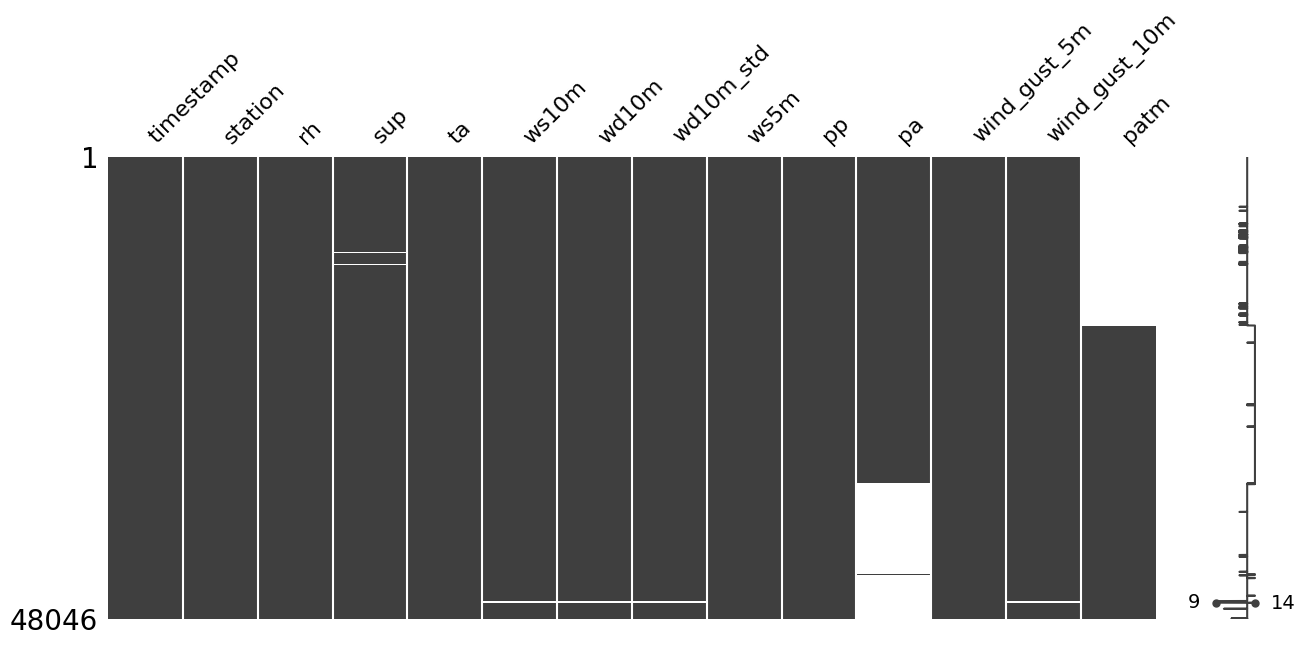

In [ ]:
matrix(df_x, figsize=(15, 6))

In [6]:
df_y = pd.concat([pd.read_excel(f'PFA {year}.xlsx', sheet_name='1830-H1 - Caudal Ecológico PFA') for year in ['2023', '2024', '2025']], axis=0)
df_y

,Fecha,Altura (cm),Caudal (L/s)
0,2023-12-05 17:18:41,NaN,6203.400957
1,2023-12-05 18:00:00,NaN,6351.295710
2,2023-12-05 19:00:00,NaN,6474.659529
3,2023-12-05 20:00:00,NaN,6581.123409
4,2023-12-05 21:00:00,NaN,6616.748156
...,...,...,...
5377,2025-08-13 08:00:00,NaN,1398.248445
5378,2025-08-13 09:00:00,NaN,1379.342127
5379,2025-08-13 10:00:00,NaN,1353.128594
5380,2025-08-13 11:00:00,NaN,1330.618013


<Axes: xlabel='Fecha'>

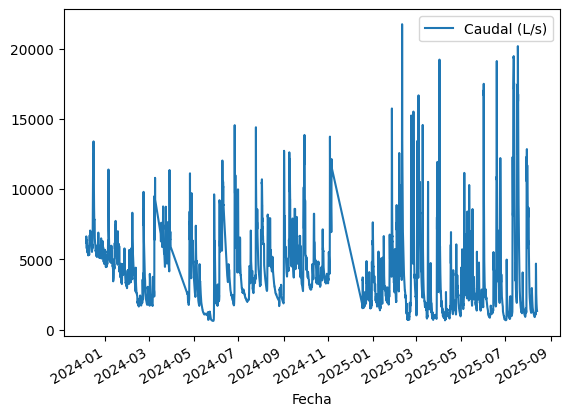

In [7]:
df_y.plot(x='Fecha', y=['Caudal (L/s)'])

In [8]:
# Ensure timestamp is datetime
df_x["timestamp"] = pd.to_datetime(df_x["timestamp"])

# Build full hourly range
full_range = pd.date_range(
    start=df_x["timestamp"].min(),
    end=df_x["timestamp"].max(),
    freq="H"
)

# Reindex df_x to the full range
df_x = (
    df_x.set_index("timestamp")
        .reindex(full_range)        # add missing hours
        .rename_axis("timestamp")   # restore column name
        .reset_index()
)

# Now merge again
df_data = df_x.merge(df_y, left_on="timestamp", right_on="Fecha", how="left")
df_data = df_data.drop(columns=["Fecha", "Altura (cm)", "station"])
df_data.sort_values("timestamp", inplace=True)
df_data

/tmp/ipykernel_3838898/1144463988.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(


,timestamp,rh,sup,ta,ws10m,wd10m,wd10m_std,ws5m,pp,pa,wind_gust_5m,wind_gust_10m,Caudal (L/s)
0,2020-01-11 19:00:00,77.04,414.7,15.980,2.389,227.20,16.41,2.051,0.0,376.0,0.000,0.000,NaN
1,2020-01-11 20:00:00,76.09,280.3,16.420,0.964,250.20,34.21,1.426,0.0,375.9,0.000,0.000,NaN
2,2020-01-11 21:00:00,91.20,144.7,14.620,0.369,239.40,10.64,0.745,0.0,375.8,0.000,0.000,NaN
3,2020-01-11 22:00:00,89.70,174.6,15.210,0.255,196.30,16.29,1.102,0.0,375.8,0.357,0.000,NaN
4,2020-01-11 23:00:00,85.70,101.9,15.920,1.876,216.80,14.12,1.390,0.0,375.8,0.288,1.621,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49693,2025-09-12 08:00:00,90.40,116.7,5.050,1.478,324.20,21.90,1.678,0.0,NaN,0.000,0.000,NaN
49694,2025-09-12 09:00:00,89.50,118.4,5.295,2.487,344.80,24.57,2.394,0.0,NaN,0.716,1.009,NaN
49695,2025-09-12 10:00:00,87.60,123.8,5.420,2.354,343.50,25.24,2.317,0.0,NaN,0.000,0.000,NaN
49696,2025-09-12 11:00:00,85.10,134.8,5.623,3.217,355.00,21.80,2.972,0.0,NaN,0.655,0.863,NaN


In [9]:
df_data = df_data[df_data['timestamp'] > df_data.dropna()['timestamp'].min()]
df_data

,timestamp,rh,sup,ta,ws10m,wd10m,wd10m_std,ws5m,pp,pa,wind_gust_5m,wind_gust_10m,Caudal (L/s)
34176,2023-12-05 19:00:00,49.40,780.8,18.370,3.589,242.00,33.46,2.579,0.0,376.8,0.000,0.000,6474.659529
34177,2023-12-05 20:00:00,47.53,610.7,19.620,2.804,241.30,43.45,1.921,0.0,376.9,0.000,0.000,6581.123409
34178,2023-12-05 21:00:00,46.43,463.8,20.430,3.864,226.50,21.34,2.130,0.0,377.0,0.209,1.060,6616.748156
34179,2023-12-05 22:00:00,45.41,342.8,19.920,2.906,235.60,28.17,2.173,0.0,376.9,0.043,0.000,6635.076566
34180,2023-12-05 23:00:00,52.20,199.6,19.270,1.505,253.50,52.61,1.644,0.0,376.6,0.000,0.000,6610.481332
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49693,2025-09-12 08:00:00,90.40,116.7,5.050,1.478,324.20,21.90,1.678,0.0,NaN,0.000,0.000,NaN
49694,2025-09-12 09:00:00,89.50,118.4,5.295,2.487,344.80,24.57,2.394,0.0,NaN,0.716,1.009,NaN
49695,2025-09-12 10:00:00,87.60,123.8,5.420,2.354,343.50,25.24,2.317,0.0,NaN,0.000,0.000,NaN
49696,2025-09-12 11:00:00,85.10,134.8,5.623,3.217,355.00,21.80,2.972,0.0,NaN,0.655,0.863,NaN


<Axes: xlabel='timestamp'>

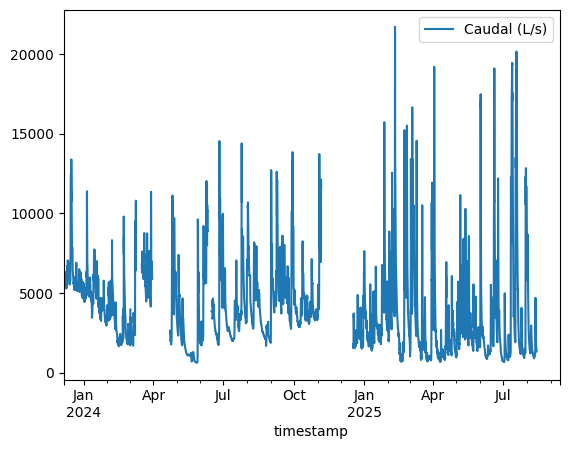

In [14]:
df_data.plot(x='timestamp', y=['Caudal (L/s)'])

<Axes: xlabel='timestamp'>

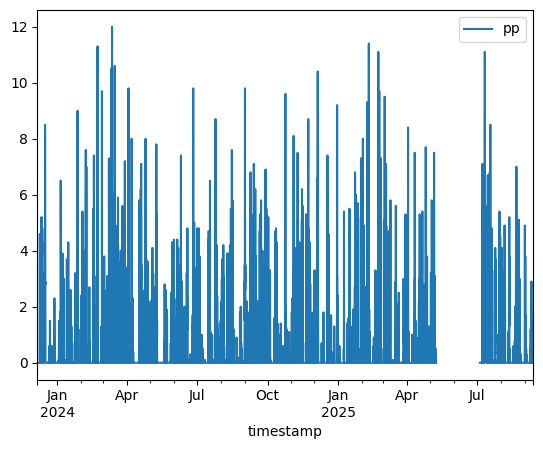

In [15]:
df_data.plot(x='timestamp', y=['pp'])

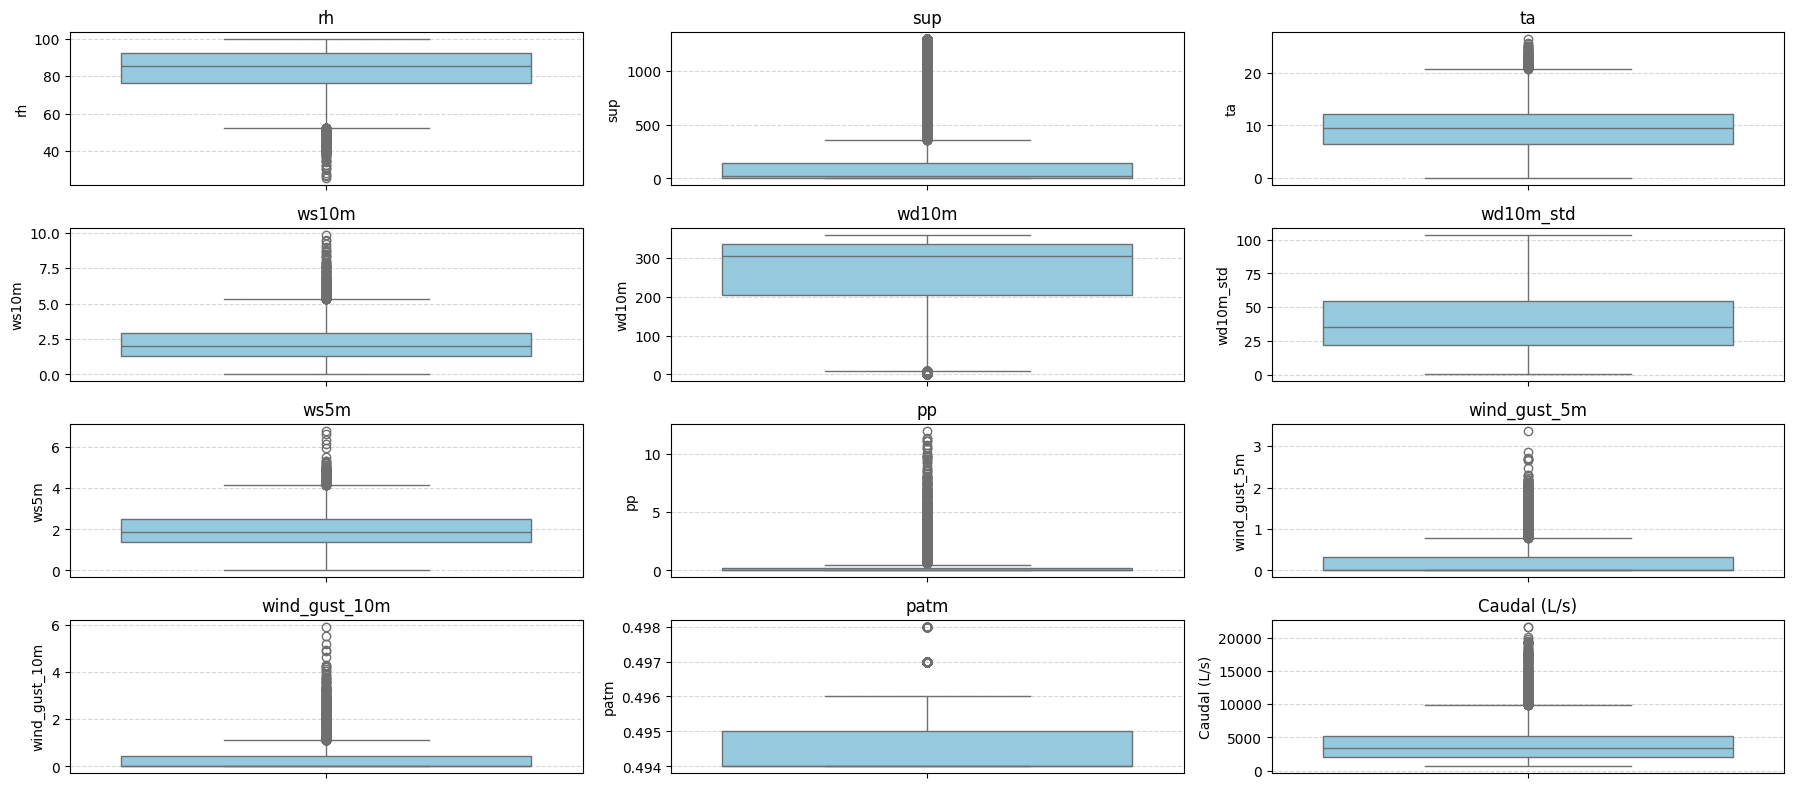

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

columns_to_plot = [
    'rh', 'sup', 'ta', 'ws10m', 'wd10m', 'wd10m_std', 'ws5m',
    'pp', 'wind_gust_5m', 'wind_gust_10m', 'patm', 'Caudal (L/s)'
]

# keep only existing columns
columns_to_plot = [c for c in columns_to_plot if c in df_data.columns]

# define grid size (e.g., 3 columns per row)
n_cols = 3
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 2*n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(columns_to_plot):
    sns.boxplot(y=df_data[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.5)

# remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('var_dist.png')
plt.show()

In [15]:
df_data = df_data.drop(columns=['pa'])

<Axes: >

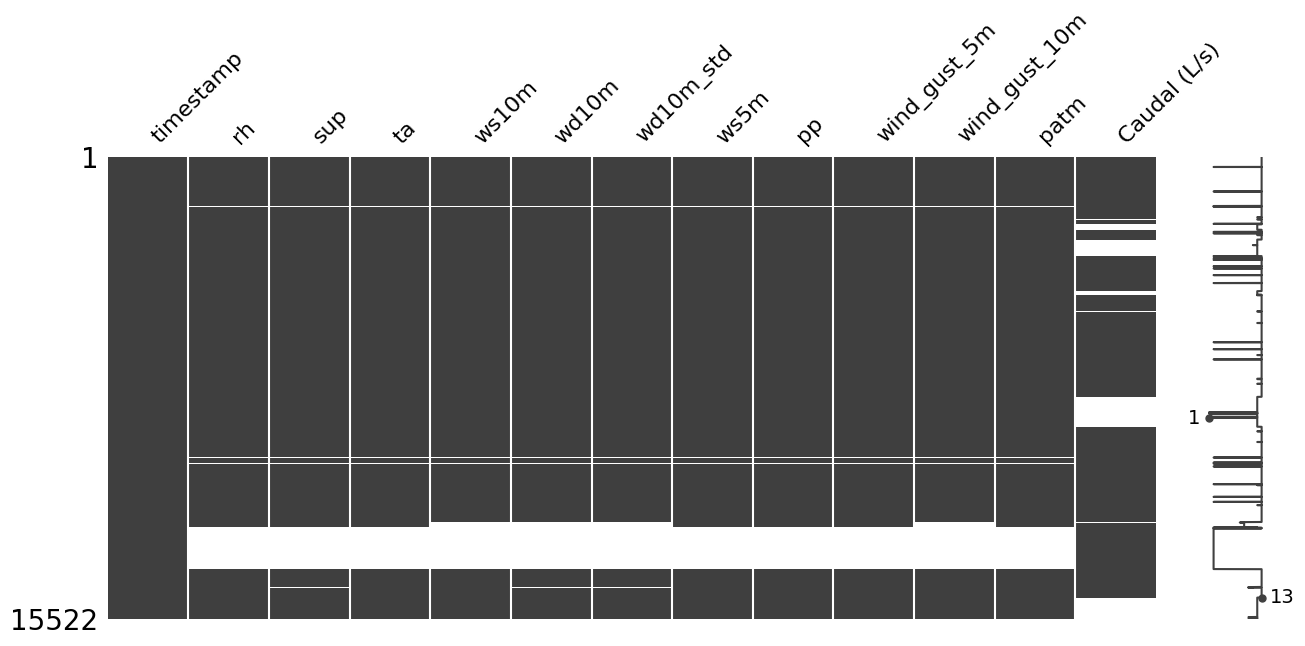

In [16]:
matrix(df_data, figsize=(15, 6))

In [17]:
print(df_data)

                timestamp     rh    sup      ta  ws10m   wd10m  wd10m_std  \
34176 2023-12-05 19:00:00  49.40  780.8  18.370  3.589  242.00      33.46   
34177 2023-12-05 20:00:00  47.53  610.7  19.620  2.804  241.30      43.45   
34178 2023-12-05 21:00:00  46.43  463.8  20.430  3.864  226.50      21.34   
34179 2023-12-05 22:00:00  45.41  342.8  19.920  2.906  235.60      28.17   
34180 2023-12-05 23:00:00  52.20  199.6  19.270  1.505  253.50      52.61   
...                   ...    ...    ...     ...    ...     ...        ...   
49693 2025-09-12 08:00:00  90.40  116.7   5.050  1.478  324.20      21.90   
49694 2025-09-12 09:00:00  89.50  118.4   5.295  2.487  344.80      24.57   
49695 2025-09-12 10:00:00  87.60  123.8   5.420  2.354  343.50      25.24   
49696 2025-09-12 11:00:00  85.10  134.8   5.623  3.217  355.00      21.80   
49697 2025-09-12 12:00:00  81.90  174.9   6.145  2.283    0.01      30.73   

        ws5m   pp  wind_gust_5m  wind_gust_10m   patm  Caudal (L/s)  
34176

In [18]:
df_data.columns

Index(['timestamp', 'rh', 'sup', 'ta', 'ws10m', 'wd10m', 'wd10m_std', 'ws5m',
       'pp', 'wind_gust_5m', 'wind_gust_10m', 'patm', 'Caudal (L/s)'],
      dtype='object')

In [19]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15522 entries, 34176 to 49697
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      15522 non-null  datetime64[ns]
 1   rh             14068 non-null  float64       
 2   sup            14028 non-null  float64       
 3   ta             14068 non-null  float64       
 4   ws10m          13891 non-null  float64       
 5   wd10m          13861 non-null  float64       
 6   wd10m_std      13861 non-null  float64       
 7   ws5m           14068 non-null  float64       
 8   pp             14068 non-null  float64       
 9   wind_gust_5m   14068 non-null  float64       
 10  wind_gust_10m  13890 non-null  float64       
 11  patm           14066 non-null  float64       
 12  Caudal (L/s)   12868 non-null  float64       
dtypes: datetime64[ns](1), float64(12)
memory usage: 1.7 MB


/home/agrospace/agrospace/mowi/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Inferred frequency: h | Forecast periods (approx for 150 days): 3600


00:01:05 - cmdstanpy - INFO - Chain [1] start processing
00:01:08 - cmdstanpy - INFO - Chain [1] done processing


Validation metrics on holdout set: {'rmse': 3229.3430006521003, 'mae': 1772.745452732854, 'mape_%': np.float64(61.194114397558884)}


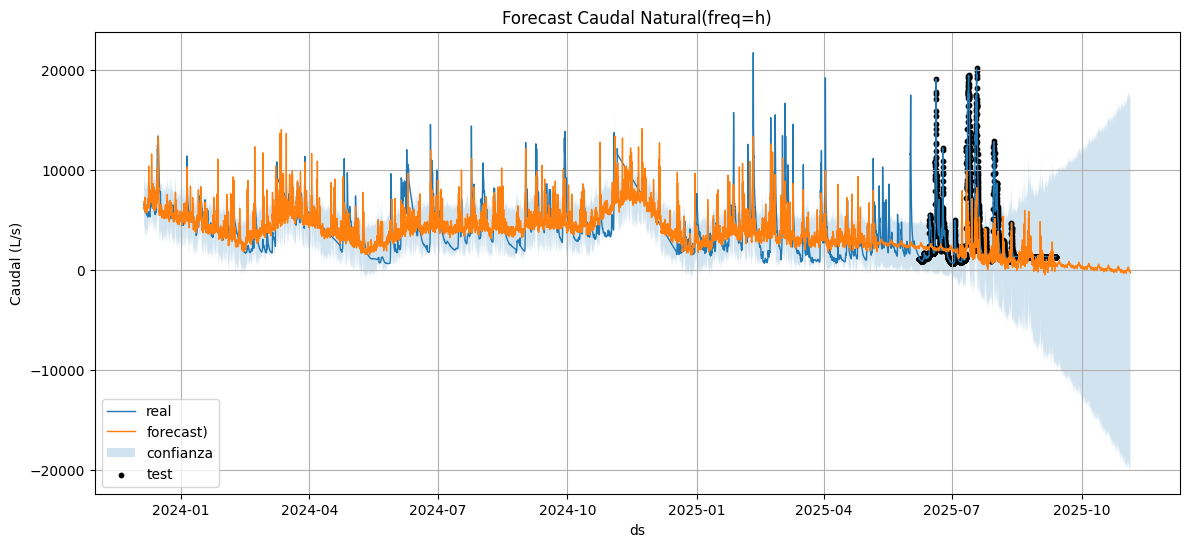

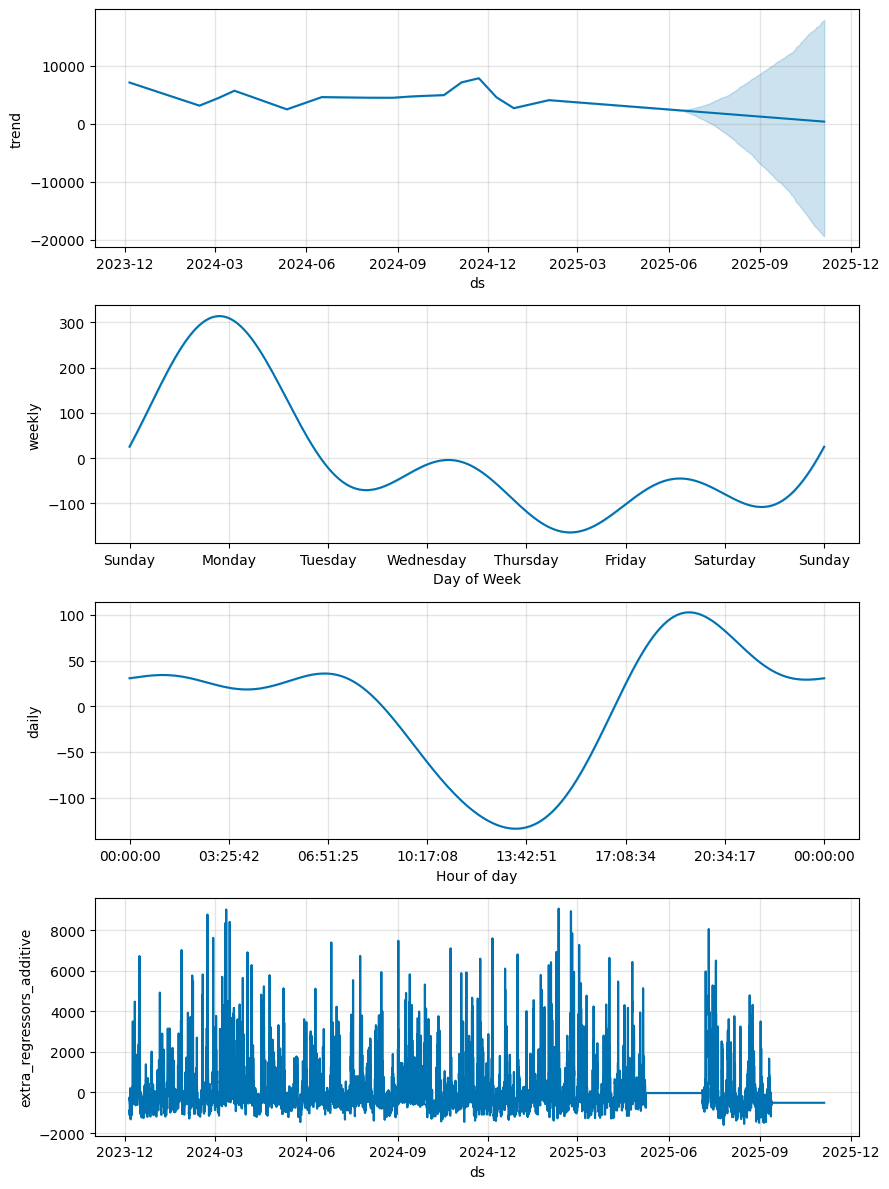

In [20]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from math import sqrt

# -----------------------
# CONFIG
# -----------------------
TARGET_COL = 'Caudal (L/s)'
TIMESTAMP_COL = 'timestamp'
# which columns to exclude as regressors (non-numeric or identifiers)
EXCLUDE_REGRESSORS = ['station', TIMESTAMP_COL, TARGET_COL]
# strategy for creating future regressors: 'last', 'median', 'linear'
future_regressor_strategy = 'last'
# number of days to forecast into the future (max 30 as requested)
forecast_days = 150
# validation proportion (for a quick train/test split)
val_frac = 0.15
# -----------------------

def prepare_df_for_prophet(df):
    """
    Returns df_prophet with columns ds, y and numeric regressors.
    Also handles missing values: forward-fill then median fill.
    """
    df = df.copy()
    # ensure timestamp is datetime
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])
    df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
    
    # rename columns for Prophet
    df_prophet = df.rename(columns={TIMESTAMP_COL: 'ds', TARGET_COL: 'y'})
    
    # select numeric regressors automatically
    numeric_cols = df_prophet.select_dtypes(include=[np.number]).columns.tolist()
    regressors = [c for c in numeric_cols if c not in ['y']]
    # but drop any explicitly excluded
    regressors = [c for c in regressors if c not in EXCLUDE_REGRESSORS]
    
    # basic missing value strategy for regressors
    # forward fill then fill remaining with median
    df_prophet[regressors] = df_prophet[regressors].ffill().fillna(df_prophet[regressors].median())
    
    # ensure no NaNs in y
    df_prophet['y'] = df_prophet['y'].interpolate().ffill().bfill()
    
    return df_prophet, regressors

def infer_frequency_and_periods(df_prophet, days):
    """
    Returns freq (pandas offset alias) and number of periods required to cover `days`.
    """
    # try to infer freq on the ds index
    df_prophet = df_prophet.set_index('ds')
    freq = pd.infer_freq(df_prophet.index)
    if freq is None:
        # fallback: resample to hourly
        freq = 'H'
    # periods to get approx `days` days
    # pandas frequency to periods per day mapping
    # approximate: use pd.Timedelta to compute number of periods per day
    one_period = pd.Timedelta(1, unit=freq)
    # if above fails, use fallback
    try:
        periods_per_day = int(pd.Timedelta(days=1) / one_period)
    except Exception:
        # for common aliases map
        alias_map = {'H':24, 'D':1, 'T':24*60, 'min':24*60}
        periods_per_day = alias_map.get(freq, 24)
    periods = periods_per_day * days
    # reset index
    df_prophet = df_prophet.reset_index()
    return freq, int(periods)

def build_future_regressors(history_df, regressors, future_len, strategy='last'):
    """
    Build a DataFrame of regressors for the future horizon.
    Simple strategies: 'last', 'median', 'linear'
    history_df: df with 'ds' and regressor columns
    Returns a DataFrame indexed by ds with regressors.
    """
    last_ds = history_df['ds'].iloc[-1]
    # infer step size from last two timestamps
    if len(history_df) >= 2:
        step = history_df['ds'].iloc[-1] - history_df['ds'].iloc[-2]
    else:
        step = pd.Timedelta(hours=1)
    
    future_dates = [last_ds + (i+1)*step for i in range(future_len)]
    future = pd.DataFrame({'ds': future_dates})
    
    if len(history_df) == 0:
        # nothing to do
        for r in regressors:
            future[r] = 0.0
        return future
    
    if strategy == 'last':
        last_vals = history_df[regressors].iloc[-1]
        for r in regressors:
            future[r] = float(last_vals[r])
    elif strategy == 'median':
        med_vals = history_df[regressors].median()
        for r in regressors:
            future[r] = float(med_vals[r])
    elif strategy == 'linear':
        # linear extrapolation using last two points per regressor
        for r in regressors:
            if len(history_df) >= 2:
                x = np.array([0,1], dtype=float)
                y = history_df[r].values[-2:].astype(float)
                # slope
                slope = (y[1]-y[0])
                extrap = [float(y[-1] + slope*(i+1)) for i in range(future_len)]
                future[r] = extrap
            else:
                future[r] = float(history_df[r].iloc[-1])
    else:
        raise ValueError("Unknown future regressor strategy")
    return future

def fit_and_forecast(df_prophet, regressors, periods, freq, future_regressor_strategy='last'):
    """
    Fit Prophet with regressors and forecast `periods` steps ahead (freq is offset alias).
    Returns model, forecast_df, train_df, test_df, y_pred_test
    """
    # train/test split: last val_frac as validation
    n = len(df_prophet)
    split = int(n * (1 - val_frac))
    train_df = df_prophet.iloc[:split].copy().reset_index(drop=True)
    test_df = df_prophet.iloc[split:].copy().reset_index(drop=True)
    
    m = Prophet()
    # add regressors
    for r in regressors:
        m.add_regressor(r)
    
    m.fit(train_df[['ds','y'] + regressors])
    
    # make predictions on test set (use test regressors available historically)
    test_pred = m.predict(test_df[['ds'] + regressors])
    
    # create future dataframe (includes historical + future)
    future_hist = df_prophet[['ds'] + regressors].copy()
    future = m.make_future_dataframe(periods=periods, freq=freq)
    # merge known regressors where available; for future rows fill using strategy
    future = future.merge(future_hist, on='ds', how='left')
    
    # generate rows where regressors are NaN (future) using strategy
    if future[regressors].isnull().any().any():
        # find how many future rows have NaNs
        future_rows = future[future[regressors].isnull().any(axis=1)]
        if len(future_rows) > 0:
            future_reg_df = build_future_regressors(df_prophet[['ds'] + regressors], regressors,
                                                   future_len=len(future_rows), strategy=future_regressor_strategy)
            # assign these generated regressor values into future DataFrame at the NaN slots in order
            future.loc[future[regressors].isnull().any(axis=1), regressors] = future_reg_df[regressors].values
    
    forecast = m.predict(future)
    
    # evaluation on test set
    y_true = test_df['y'].values
    y_pred = test_pred['yhat'].values
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.where(y_true==0, 1e-8, y_true)))) * 100
    
    metrics = {'rmse': rmse, 'mae': mae, 'mape_%': mape}
    
    return m, forecast, train_df, test_df, test_pred, metrics

def plot_forecast_vs_history(forecast, df_prophet, train_df, test_df, regressors, title_suffix=''):
    """
    Plots history & forecast (yhat) with confidence intervals and overlays test actuals.
    """
    plt.figure(figsize=(14,6))
    # plot history
    plt.plot(df_prophet['ds'], df_prophet['y'], label='real', linewidth=1)
    # plot forecast yhat for future+history
    plt.plot(forecast['ds'], forecast['yhat'], label='forecast)', linewidth=1)
    # CI
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.2, label='confianza')
    # overlay test actuals
    plt.scatter(test_df['ds'], test_df['y'], color='k', s=10, label='test')
    plt.legend()
    plt.title('Forecast Caudal Natural' + title_suffix)
    plt.xlabel('ds')
    plt.ylabel(TARGET_COL)
    plt.grid(True)
    plt.show()

def plot_prophet_components(model, forecast):
    fig = model.plot_components(forecast)
    plt.show()

# === Main runner (call this with your df_data) ===
def run_prophet_pipeline(df_data):
    df_prophet, regressors = prepare_df_for_prophet(df_data)
    freq, periods = infer_frequency_and_periods(df_prophet, forecast_days)
    print(f"Inferred frequency: {freq} | Forecast periods (approx for {forecast_days} days): {periods}")
    model, forecast, train_df, test_df, test_pred, metrics = fit_and_forecast(df_prophet, regressors, periods, freq, future_regressor_strategy)
    print("Validation metrics on holdout set:", metrics)
    
    # plot results
    plot_forecast_vs_history(forecast, df_prophet, train_df, test_df, regressors, title_suffix=f"(freq={freq})")
    plot_prophet_components(model, forecast)
    
    # return objects for further inspection
    return {
        'model': model,
        'forecast': forecast,
        'train_df': train_df,
        'test_df': test_df,
        'test_pred': test_pred,
        'metrics': metrics,
        'regressors': regressors
    }

# -----------------------
# Example usage (paste and run)
# -----------------------
# assuming your dataframe is called df_data (as you said)
result = run_prophet_pipeline(df_data)

# If you want to save forecast results to CSV:
result['forecast'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('caudal_forecast.csv', index=False)


Inferred frequency: h | Forecast periods (approx for 150 days): 3600


10:33:22 - cmdstanpy - INFO - Chain [1] start processing
10:33:27 - cmdstanpy - INFO - Chain [1] done processing


Validation metrics on holdout set: {'rmse': 3352.905801910682, 'mae': 2269.9402209891186, 'mape_%': np.float64(75.23072323732899)}


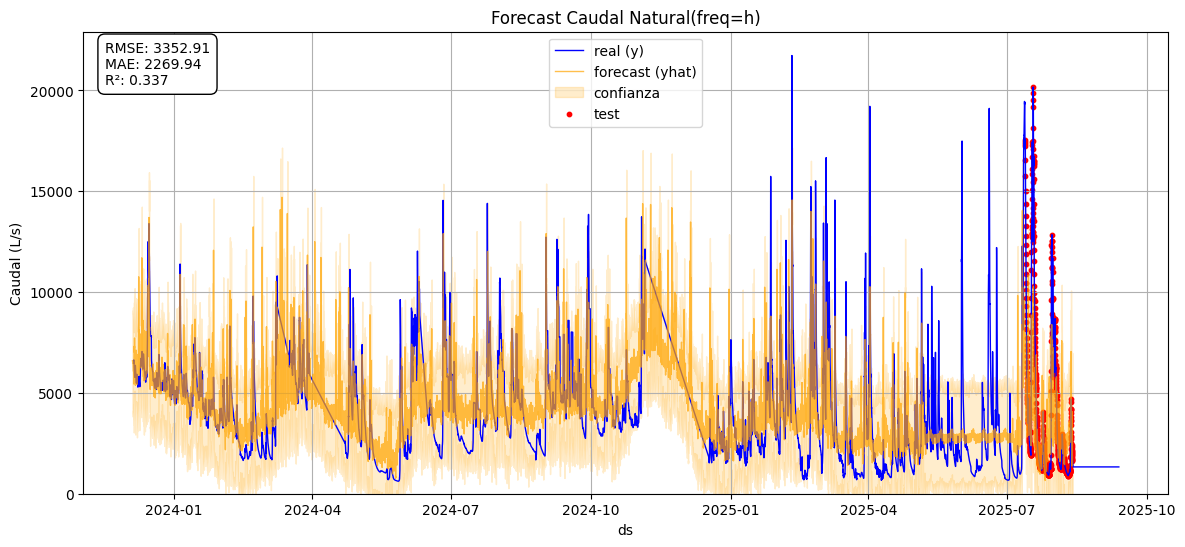

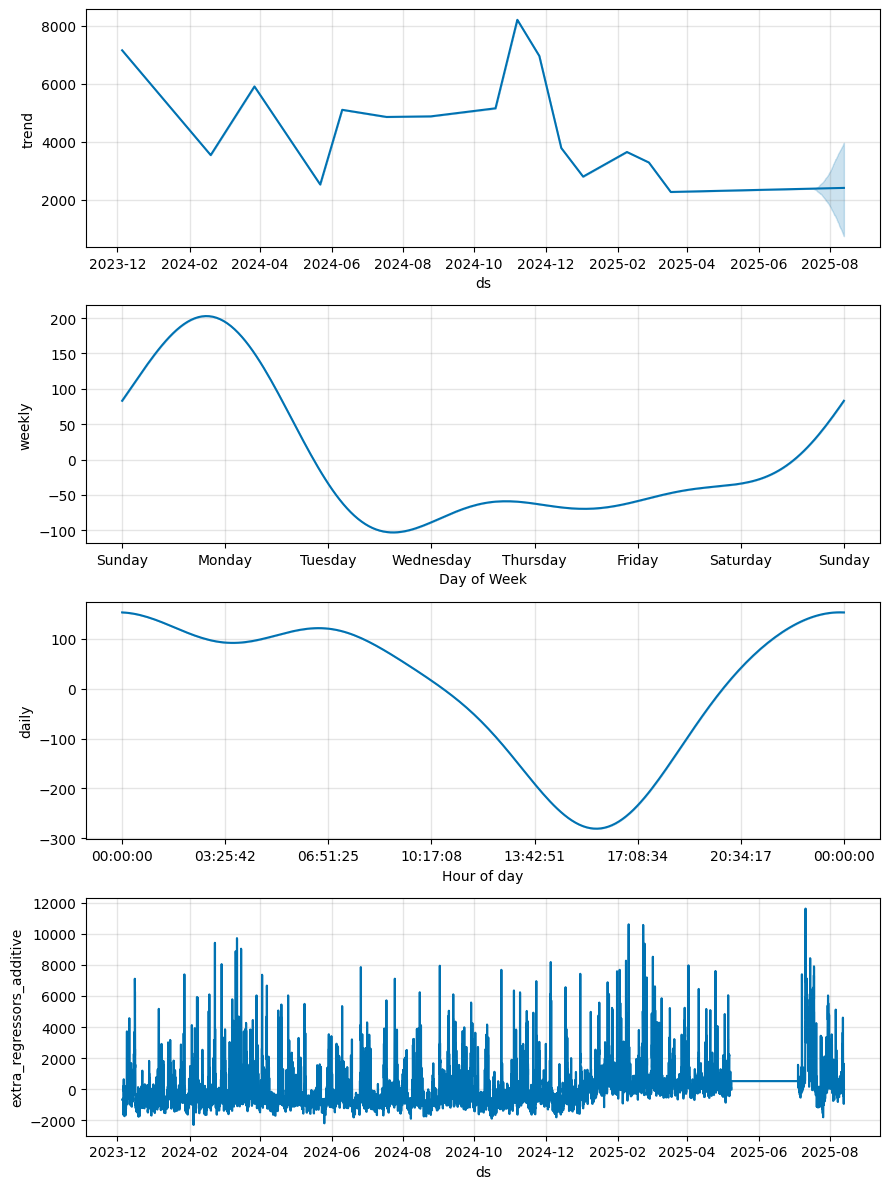

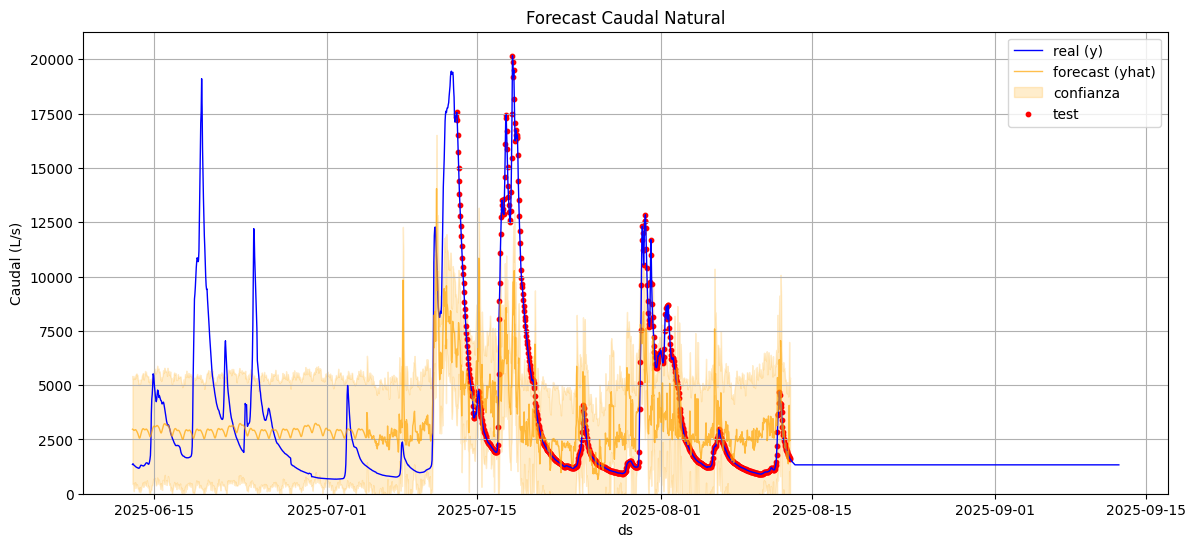

In [12]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from math import sqrt

# -----------------------
# CONFIG
# -----------------------
TARGET_COL = 'Caudal (L/s)'
TIMESTAMP_COL = 'timestamp'
# which columns to exclude as regressors (non-numeric or identifiers)
EXCLUDE_REGRESSORS = ['station', TIMESTAMP_COL, TARGET_COL]
# strategy for creating future regressors: 'last', 'median', 'linear'
future_regressor_strategy = 'last'
# number of days to forecast into the future (max 30 as requested)
forecast_days = 150
# validation proportion (for a quick train/test split)
val_frac = 0.15
# -----------------------

def prepare_df_for_prophet(df):
    """
    Returns df_prophet with columns ds, y and numeric regressors.
    Also handles missing values: forward-fill then median fill.
    """
    df = df.copy()
    # ensure timestamp is datetime
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])
    df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
    
    # rename columns for Prophet
    df_prophet = df.rename(columns={TIMESTAMP_COL: 'ds', TARGET_COL: 'y'})
    
    # select numeric regressors automatically
    numeric_cols = df_prophet.select_dtypes(include=[np.number]).columns.tolist()
    regressors = [c for c in numeric_cols if c not in ['y']]
    # but drop any explicitly excluded
    regressors = [c for c in regressors if c not in EXCLUDE_REGRESSORS]
    
    # basic missing value strategy for regressors
    # forward fill then fill remaining with median
    df_prophet[regressors] = df_prophet[regressors].ffill().fillna(df_prophet[regressors].median())
    
    # ensure no NaNs in y
    df_prophet['y'] = df_prophet['y'].interpolate().ffill().bfill()
    
    return df_prophet, regressors

def infer_frequency_and_periods(df_prophet, days):
    """
    Returns freq (pandas offset alias) and number of periods required to cover `days`.
    """
    # try to infer freq on the ds index
    df_prophet = df_prophet.set_index('ds')
    freq = pd.infer_freq(df_prophet.index)
    if freq is None:
        # fallback: resample to hourly
        freq = 'H'
    # periods to get approx `days` days
    # pandas frequency to periods per day mapping
    # approximate: use pd.Timedelta to compute number of periods per day
    one_period = pd.Timedelta(1, unit=freq)
    # if above fails, use fallback
    try:
        periods_per_day = int(pd.Timedelta(days=1) / one_period)
    except Exception:
        # for common aliases map
        alias_map = {'H':24, 'D':1, 'T':24*60, 'min':24*60}
        periods_per_day = alias_map.get(freq, 24)
    periods = periods_per_day * days
    # reset index
    df_prophet = df_prophet.reset_index()
    return freq, int(periods)

def build_future_regressors(history_df, regressors, future_len, strategy='last'):
    """
    Build a DataFrame of regressors for the future horizon.
    Simple strategies: 'last', 'median', 'linear'
    history_df: df with 'ds' and regressor columns
    Returns a DataFrame indexed by ds with regressors.
    """
    last_ds = history_df['ds'].iloc[-1]
    # infer step size from last two timestamps
    if len(history_df) >= 2:
        step = history_df['ds'].iloc[-1] - history_df['ds'].iloc[-2]
    else:
        step = pd.Timedelta(hours=1)
    
    future_dates = [last_ds + (i+1)*step for i in range(future_len)]
    future = pd.DataFrame({'ds': future_dates})
    
    if len(history_df) == 0:
        # nothing to do
        for r in regressors:
            future[r] = 0.0
        return future
    
    if strategy == 'last':
        last_vals = history_df[regressors].iloc[-1]
        for r in regressors:
            future[r] = float(last_vals[r])
    elif strategy == 'median':
        med_vals = history_df[regressors].median()
        for r in regressors:
            future[r] = float(med_vals[r])
    elif strategy == 'linear':
        # linear extrapolation using last two points per regressor
        for r in regressors:
            if len(history_df) >= 2:
                x = np.array([0,1], dtype=float)
                y = history_df[r].values[-2:].astype(float)
                # slope
                slope = (y[1]-y[0])
                extrap = [float(y[-1] + slope*(i+1)) for i in range(future_len)]
                future[r] = extrap
            else:
                future[r] = float(history_df[r].iloc[-1])
    else:
        raise ValueError("Unknown future regressor strategy")
    return future

def fit_and_forecast(df_prophet, regressors, train_start, val_start, forecast_end,
                                future_regressor_strategy='last'):
    """
    Fit Prophet with regressors using explicit date ranges:
      train_start: training start date ("yyyymmdd")
      val_start: validation start date ("yyyymmdd"), also end of training
      forecast_end: forecast horizon end date ("yyyymmdd")
    """
    # convert to timestamps
    train_start = pd.to_datetime(train_start, format="%Y%m%d")
    val_start = pd.to_datetime(val_start, format="%Y%m%d")
    forecast_end = pd.to_datetime(forecast_end, format="%Y%m%d")
    
    # filter data
    df_filtered = df_prophet[(df_prophet['ds'] >= train_start) & (df_prophet['ds'] <= forecast_end)].copy()
    
    # split train/val
    train_df = df_filtered[df_filtered['ds'] < val_start].copy().reset_index(drop=True)
    test_df = df_filtered[df_filtered['ds'] >= val_start].copy().reset_index(drop=True)
    
    # infer frequency
    full_freq = pd.infer_freq(df_prophet['ds'])
    if full_freq is None:
        full_freq = 'D'  # fallback daily
    
    # build model
    m = Prophet()
    for r in regressors:
        m.add_regressor(r)
    m.fit(train_df[['ds', 'y'] + regressors])
    
    # ----------------------------
    # Build continuous future from start→end (fills gaps too)
    # ----------------------------
    future_dates = pd.date_range(start=train_start, end=forecast_end, freq=full_freq)
    future = pd.DataFrame({"ds": future_dates})
    
    # merge regressors for known dates
    future = future.merge(df_prophet[['ds'] + regressors], on='ds', how='left')
    
    # fill missing regressors
    if future[regressors].isnull().any().any():
        future[regressors] = future[regressors].ffill().fillna(future[regressors].median())
    
    # predict for all dates
    forecast = m.predict(future)
    
    # validation predictions (restricted to test dates)
    test_pred = forecast[forecast['ds'].isin(test_df['ds'])].copy()
    
    # evaluation
    y_true = test_df['y'].values
    y_pred = test_pred['yhat'].values
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.where(y_true==0, 1e-8, y_true)))) * 100
    metrics = {'rmse': rmse, 'mae': mae, 'mape_%': mape}
    
    return m, forecast, train_df, test_df, test_pred, metrics


def plot_forecast_vs_history(forecast, df_prophet, train_df, test_df, regressors, title_suffix=''):
    plt.figure(figsize=(14,6))
    
    plt.plot(df_prophet['ds'], df_prophet['y'], label='real (y)', linewidth=1, color='blue')
    plt.plot(forecast['ds'], forecast['yhat'], label='forecast (yhat)', linewidth=1, alpha=0.7, color='orange')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                     alpha=0.2, label='confianza', color='orange')
    plt.scatter(test_df['ds'], test_df['y'], color='r', s=10, label='test')
    
    # --- Compute metrics safely ---
    df_merge = test_df[['ds','y']].merge(forecast[['ds','yhat']], on='ds', how='left')
    df_merge = df_merge.dropna(subset=['yhat'])  # remove any NaNs
    y_true = df_merge['y'].values
    y_pred = df_merge['yhat'].values
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    metrics_text = f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}"
    plt.text(0.02, 0.98, metrics_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
    
    plt.legend()
    plt.title('Forecast Caudal Natural' + title_suffix)
    plt.xlabel('ds')
    plt.ylabel(TARGET_COL)
    plt.ylim(0, None)
    plt.grid(True)
    plt.show()


def plot_forecast_closeup(forecast, df_prophet, train_df, test_df, regressors, title_suffix='', plot_start=None):
    """
    Plots history & forecast (yhat) with confidence intervals and overlays test actuals.
    
    Parameters:
    - plot_start: string "yyyymmdd" or pd.Timestamp, earliest date to show in plot (optional)
    """
    plt.figure(figsize=(14,6))
    
    # convert plot_start to Timestamp if string
    if plot_start is not None:
        plot_start = pd.to_datetime(plot_start, format="%Y%m%d") if isinstance(plot_start, str) else plot_start
        df_prophet_plot = df_prophet[df_prophet['ds'] >= plot_start]
        forecast_plot = forecast[forecast['ds'] >= plot_start]
        test_df_plot = test_df[test_df['ds'] >= plot_start]
    else:
        df_prophet_plot = df_prophet
        forecast_plot = forecast
        test_df_plot = test_df
    
    # plot history
    plt.plot(df_prophet_plot['ds'], df_prophet_plot['y'], label='real (y)', linewidth=1, color='blue')
    # plot forecast yhat for future+history
    plt.plot(forecast_plot['ds'], forecast_plot['yhat'], label='forecast (yhat)', linewidth=1, alpha=0.7, color='orange')
    # CI
    plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'], 
                     alpha=0.2, label='confianza', color='orange')
    # overlay test actuals
    plt.scatter(test_df_plot['ds'], test_df_plot['y'], color='r', s=10, label='test')
    
    plt.legend()
    plt.title('Forecast Caudal Natural' + title_suffix)
    plt.xlabel('ds')
    plt.ylim(0, None)
    plt.ylabel(TARGET_COL)
    plt.grid(True)
    plt.show()

def plot_prophet_components(model, forecast):
    fig = model.plot_components(forecast)
    plt.show()

# === Main runner (call this with your df_data) ===
def run_prophet_pipeline(df_data):
    df_prophet, regressors = prepare_df_for_prophet(df_data)
    freq, periods = infer_frequency_and_periods(df_prophet, forecast_days)
    print(f"Inferred frequency: {freq} | Forecast periods (approx for {forecast_days} days): {periods}")
    model, forecast, train_df, test_df, test_pred, metrics = fit_and_forecast(
        df_prophet,
        regressors,
        train_start="20231205",
        val_start="20250713",
        forecast_end="2025813"
    )
    print("Validation metrics on holdout set:", metrics)
    
    # plot results
    plot_forecast_vs_history(forecast, df_prophet, train_df, test_df, regressors, title_suffix=f"(freq={freq})")
    plot_prophet_components(model, forecast)
    plot_forecast_closeup(
        forecast, df_prophet, train_df, test_df, regressors,
        title_suffix='',
        plot_start='20250613'  # start plotting from this date
    )
    
    # return objects for further inspection
    return {
        'model': model,
        'forecast': forecast,
        'train_df': train_df,
        'test_df': test_df,
        'test_pred': test_pred,
        'metrics': metrics,
        'regressors': regressors
    }

# -----------------------
# Example usage (paste and run)
# -----------------------
# assuming your dataframe is called df_data (as you said)
result = run_prophet_pipeline(df_data)

# If you want to save forecast results to CSV:
result['forecast'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('caudal_forecast.csv', index=False)

10:34:01 - cmdstanpy - INFO - Chain [1] start processing
10:34:01 - cmdstanpy - INFO - Chain [1] done processing


Metrics over the whole prediction vs real data: {'rmse': 1681.5819036261141, 'mae': 1255.3523344715447, 'mape_%': np.float64(47.628830427798505), 'r2': 0.5342140678700664, 'used_rows': 545, 'total_rows': 545}
Train rows: 539, Train used for fit (after filling regressors): 539
Test rows total: 6, Test rows used for metrics (complete rows): 0
Validation metrics on holdout set: {'rmse': 1681.5819036261141, 'mae': 1255.3523344715447, 'mape_%': np.float64(47.628830427798505), 'r2': 0.5342140678700664, 'used_rows': 545, 'total_rows': 545}


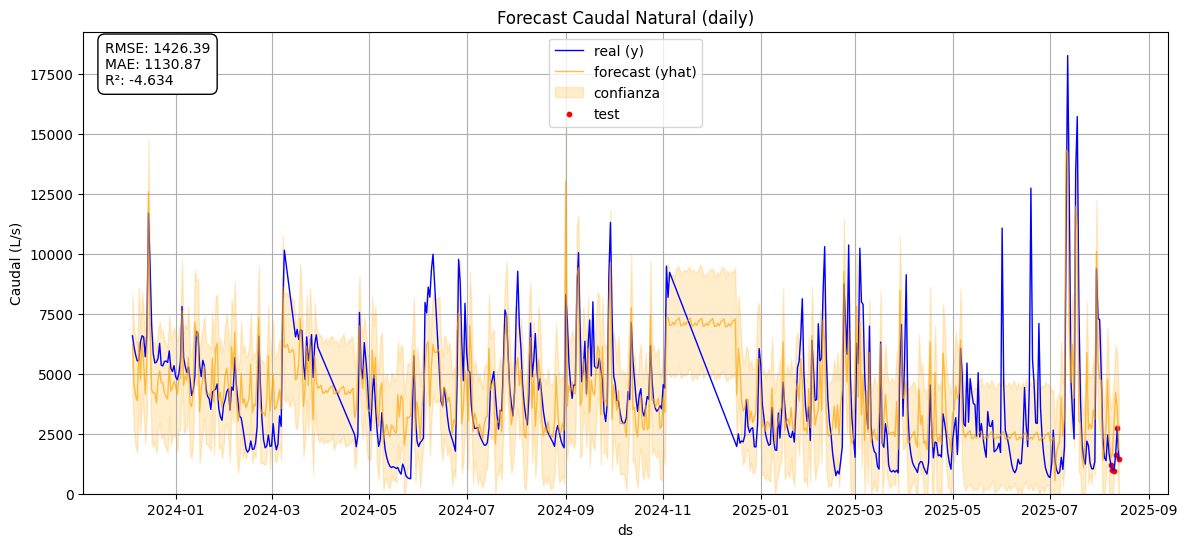

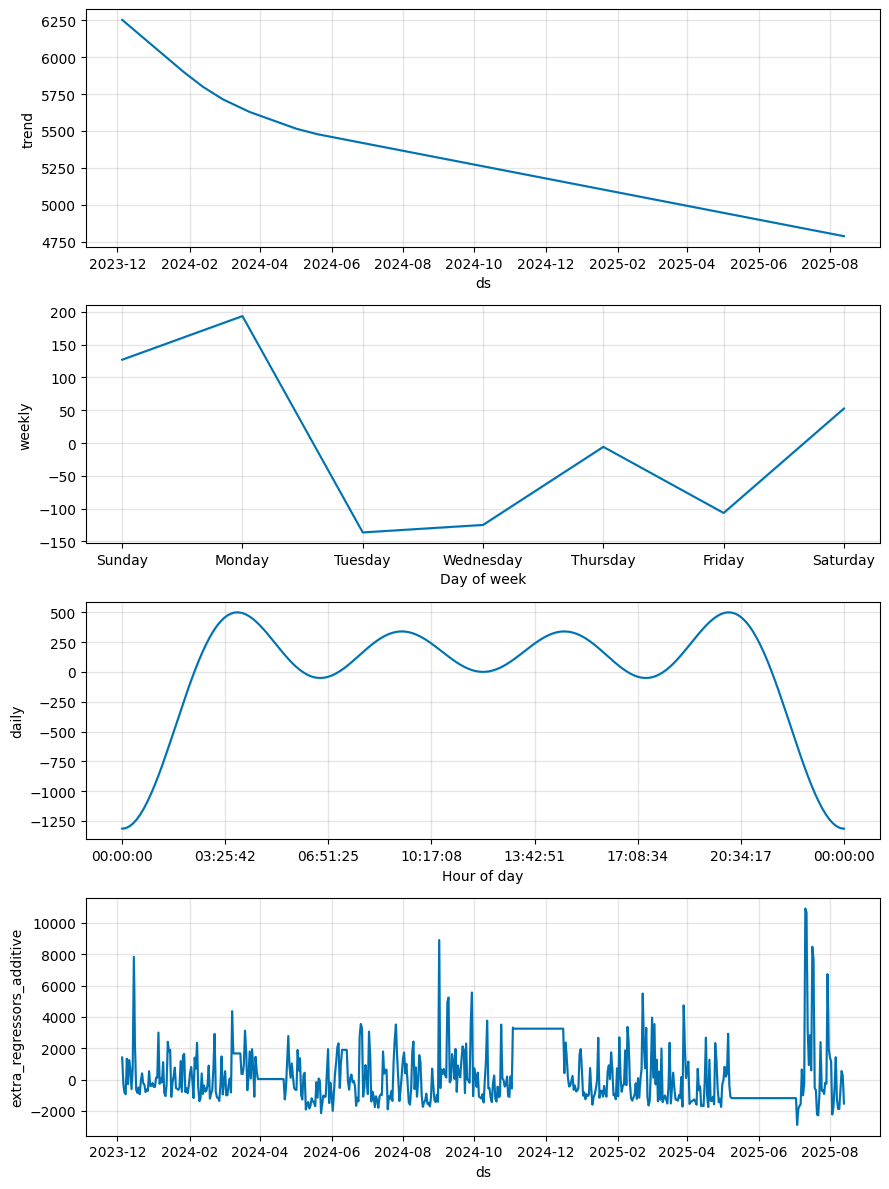

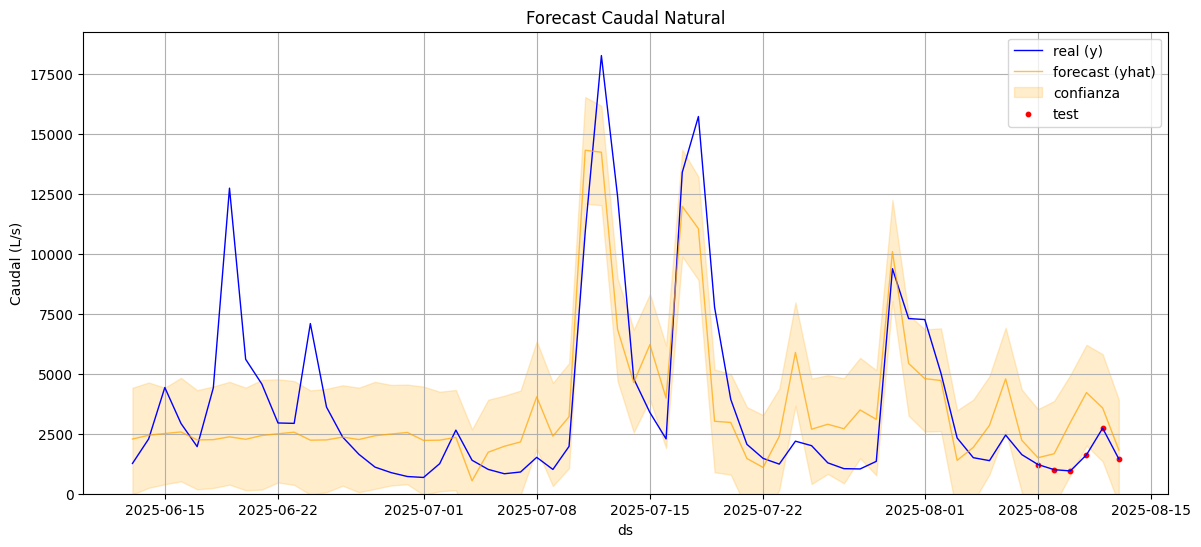

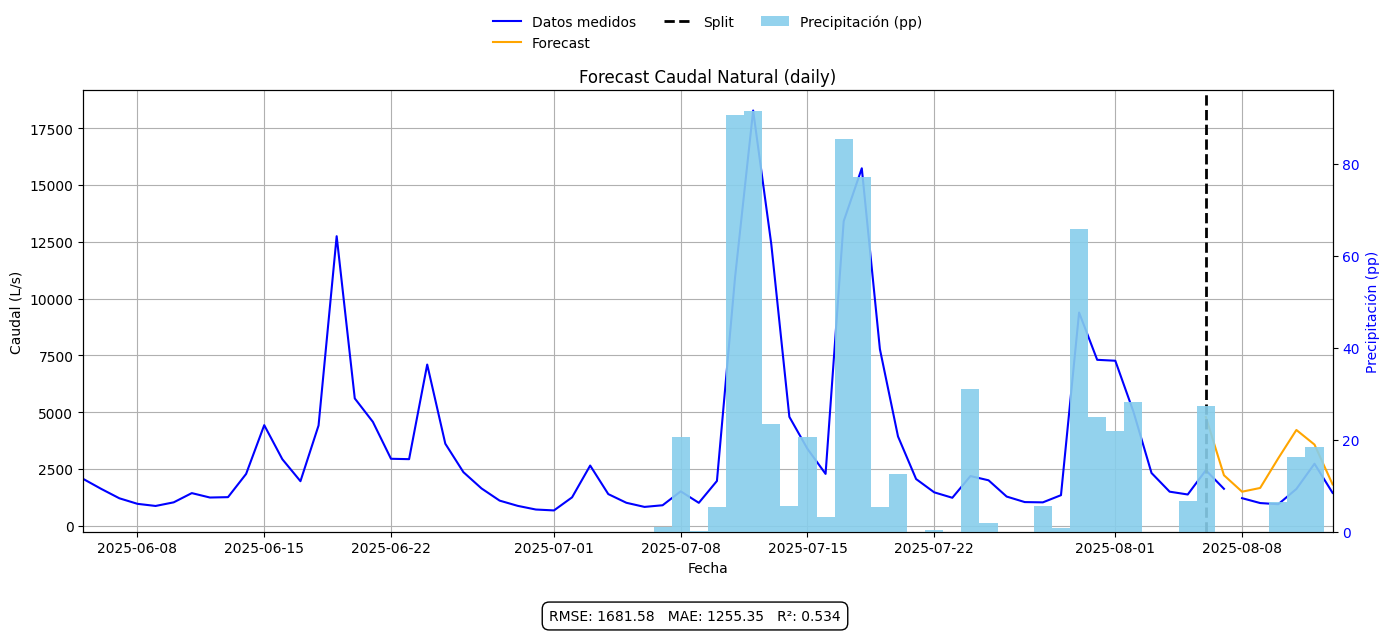

In [13]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------
# CONFIG
# -----------------------
TARGET_COL = 'Caudal (L/s)'
TIMESTAMP_COL = 'timestamp'
EXCLUDE_REGRESSORS = ['station', TIMESTAMP_COL, TARGET_COL]
future_regressor_strategy = 'last'
# -----------------------

# --- Aggregation to daily ---
def aggregate_to_daily(df):
    """
    Aggregates hourly/finer data to daily:
    - Target ('Caudal (L/s)'): sum per day
    - Precipitation ('pp'): sum per day
    - Other numeric regressors: mean per day
    """
    df = df.copy()
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])
    df = df.set_index(TIMESTAMP_COL)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if TARGET_COL in numeric_cols:
        numeric_cols.remove(TARGET_COL)
    if 'pp' in numeric_cols:
        numeric_cols.remove('pp')
    
    agg_dict = {TARGET_COL: 'mean', 'pp': 'sum'}
    for col in numeric_cols:
        agg_dict[col] = 'mean'
    
    df_daily = df.resample('D').agg(agg_dict).reset_index()
    return df_daily

# --- Prepare for Prophet ---
def prepare_df_for_prophet(df):
    df = df.copy()
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL])
    df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
    
    df_prophet = df.rename(columns={TIMESTAMP_COL: 'ds', TARGET_COL: 'y'})
    
    # Identify regressors
    numeric_cols = df_prophet.select_dtypes(include=[np.number]).columns.tolist()
    regressors = [c for c in numeric_cols if c not in ['y'] and c not in EXCLUDE_REGRESSORS]
    
    # Keep regressors intact, but drop missing y rows
    df_prophet = df_prophet.dropna(subset=['y'])
    
    return df_prophet, regressors

# --- Build future regressors ---
def build_future_regressors(history_df, regressors, future_len, strategy='last'):
    last_ds = history_df['ds'].iloc[-1]
    if len(history_df) >= 2:
        step = history_df['ds'].iloc[-1] - history_df['ds'].iloc[-2]
    else:
        step = pd.Timedelta(days=1)
    
    future_dates = [last_ds + (i+1)*step for i in range(future_len)]
    future = pd.DataFrame({'ds': future_dates})
    
    if len(history_df) == 0:
        for r in regressors:
            future[r] = 0.0
        return future
    
    if strategy == 'last':
        last_vals = history_df[regressors].iloc[-1]
        for r in regressors:
            future[r] = float(last_vals[r])
    elif strategy == 'median':
        med_vals = history_df[regressors].median()
        for r in regressors:
            future[r] = float(med_vals[r])
    elif strategy == 'linear':
        for r in regressors:
            if len(history_df) >= 2:
                y = history_df[r].values[-2:].astype(float)
                slope = y[1]-y[0]
                future[r] = [float(y[-1] + slope*(i+1)) for i in range(future_len)]
            else:
                future[r] = float(history_df[r].iloc[-1])
    else:
        raise ValueError("Unknown future regressor strategy")
    return future

def compute_metrics_overall(forecast, df_prophet, regressors=None, require_regressors=False):
    """
    Compute metrics comparing the full forecast to the real measurements.
    
    - forecast: DataFrame with at least ['ds','yhat'] (can also have yhat_lower/upper)
    - df_prophet: DataFrame with at least ['ds','y'] (original measured values)
    - regressors: optional list of regressor column names to require (if require_regressors=True)
    - require_regressors: if True, rows with any NaN in regressors are excluded
    
    Returns: dict with rmse, mae, mape_%, r2, used_rows, total_rows
    """
    # Keep only necessary cols and merge on ds
    left = df_prophet[['ds', 'y']].copy()
    merged = left.merge(forecast[['ds', 'yhat']], on='ds', how='inner')
    
    # If user asked to require regressors, join them too (if available)
    if require_regressors and regressors:
        # try to attach regressors from df_prophet (they should be there)
        for r in regressors:
            if r not in df_prophet.columns:
                raise KeyError(f"Regressor '{r}' not found in df_prophet")
        # merged already has ds,y; get regressors from original and merge
        merged = df_prophet[['ds'] + regressors + ['y']].merge(merged[['ds','yhat']], on='ds', how='inner')
        mask = merged['y'].notna() & (~merged[regressors].isnull().any(axis=1))
    else:
        mask = merged['y'].notna()
    
    used_rows = int(mask.sum())
    total_rows = int(left.shape[0])
    
    if used_rows == 0:
        return {'rmse': np.nan, 'mae': np.nan, 'mape_%': np.nan, 'r2': np.nan,
                'used_rows': used_rows, 'total_rows': total_rows}
    
    y_true = merged.loc[mask, 'y'].values
    y_pred = merged.loc[mask, 'yhat'].values

    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    # safe MAPE
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
    r2   = r2_score(y_true, y_pred)

    return {'rmse': rmse, 'mae': mae, 'mape_%': mape, 'r2': r2,
            'used_rows': used_rows, 'total_rows': total_rows}

# --- Fit and forecast ---
def fit_and_forecast(df_prophet, regressors, train_start, val_start, forecast_end,
                     future_regressor_strategy='last'):
    """
    Robust fit+forecast:
      - fill regressors for training (ffill -> median) so model sees consistent regressors
      - build full continuous future from train_start -> forecast_end
      - fill future regressors according to future_regressor_strategy
      - compute metrics only on rows with observed y and all regressors present
    """
    train_start = pd.to_datetime(train_start, format="%Y%m%d")
    val_start = pd.to_datetime(val_start, format="%Y%m%d")
    forecast_end = pd.to_datetime(forecast_end, format="%Y%m%d")

    # filter window
    df_filtered = df_prophet[(df_prophet['ds'] >= train_start) & (df_prophet['ds'] <= forecast_end)].copy()

    train_df = df_filtered[df_filtered['ds'] < val_start].copy().reset_index(drop=True)
    test_df  = df_filtered[df_filtered['ds'] >= val_start].copy().reset_index(drop=True)

    # --- Fill regressors for training (so we don't drop rows due to missing regressors) ---
    if regressors:
        train_for_fit = train_df.copy()
        # forward-fill then fill remaining with median (same as earlier working code)
        train_for_fit[regressors] = train_for_fit[regressors].ffill().fillna(train_for_fit[regressors].median())
    else:
        train_for_fit = train_df.copy()

    # Fit Prophet on the prepared training set
    m = Prophet(daily_seasonality=True)
    for r in regressors:
        m.add_regressor(r)
    m.fit(train_for_fit[['ds', 'y'] + regressors])

    # --- Build continuous future from start -> forecast_end (covers gaps) ---
    # infer frequency from df_prophet (fallback daily)
    freq = pd.infer_freq(df_prophet['ds'])
    if freq is None:
        freq = 'D'
    future_dates = pd.date_range(start=train_start, end=forecast_end, freq=freq)
    future = pd.DataFrame({"ds": future_dates})

    # merge known regressors from df_filtered (may be NaN in gap areas)
    future = future.merge(df_filtered[['ds'] + regressors], on='ds', how='left')

    # Fill missing regressors in future:
    #  - try to ffill from historical known values first
    #  - then apply strategy for any remaining NaNs (last/median/linear)
    if regressors:
        future[regressors] = future[regressors].ffill()
        # if still NaNs remain, fill by strategy
        if future[regressors].isnull().any().any():
            nan_mask = future[regressors].isnull().any(axis=1)
            n_nan = nan_mask.sum()
            if n_nan > 0:
                # build regressor values for those rows
                history_for_strategy = df_filtered[['ds'] + regressors].drop_duplicates(subset=['ds']).sort_values('ds')
                fut_reg_df = build_future_regressors(history_for_strategy, regressors, n_nan, strategy=future_regressor_strategy)
                future.loc[nan_mask, regressors] = fut_reg_df[regressors].values

        # if any remaining NaNs (edge case), fill with median
        future[regressors] = future[regressors].fillna(future[regressors].median())

    # Forecast over entire future (covers training period, gaps, validation, and beyond if included)
    forecast = m.predict(future)

    # --- Prepare test predictions aligned with test_df ---
    test_pred = forecast[forecast['ds'].isin(test_df['ds'])].copy()

    # --- Metrics: only where y AND all regressors are present in test_df ---
    if regressors:
        merged = test_df[['ds', 'y'] + regressors].merge(test_pred[['ds', 'yhat']], on='ds', how='inner')
        valid_mask = merged['y'].notna() & (~merged[regressors].isnull().any(axis=1))
    else:
        merged = test_df[['ds', 'y']].merge(test_pred[['ds', 'yhat']], on='ds', how='inner')
        valid_mask = merged['y'].notna()

    used = merged[valid_mask].shape[0]
    total_test = test_df.shape[0]
    # compute metrics if we have valid rows
    metrics = compute_metrics_overall(forecast, df_prophet, regressors=regressors, require_regressors=False)
    print("Metrics over the whole prediction vs real data:", metrics)

    # Print debug info so you can see what was used
    print(f"Train rows: {train_df.shape[0]}, Train used for fit (after filling regressors): {train_for_fit.shape[0]}")
    print(f"Test rows total: {total_test}, Test rows used for metrics (complete rows): {used}")

    return m, forecast, train_df, test_df, test_pred, metrics



# --- Plotting functions ---
def plot_forecast_vs_history(forecast, df_prophet, train_df, test_df, regressors, title_suffix=''):
    plt.figure(figsize=(14,6))
    
    # Plot history
    plt.plot(df_prophet['ds'], df_prophet['y'], label='real (y)', linewidth=1, color='blue')
    plt.plot(forecast['ds'], forecast['yhat'], label='forecast (yhat)', linewidth=1, alpha=0.7, color='orange')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], alpha=0.2, label='confianza', color='orange')
    plt.scatter(test_df['ds'], test_df['y'], color='r', s=10, label='test')
    
    # Calculate metrics
    y_true = test_df['y'].values
    y_pred = forecast.loc[forecast['ds'].isin(test_df['ds']), 'yhat'].values
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Add metrics in a white box
    metrics_text = f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.3f}"
    plt.text(0.02, 0.98, metrics_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
    
    plt.legend()
    plt.title('Forecast Caudal Natural' + title_suffix)
    plt.xlabel('ds')
    plt.ylabel(TARGET_COL)
    plt.ylim(0, None)
    plt.grid(True)
    plt.show()

def plot_forecast_closeup(forecast, df_prophet, train_df, test_df, regressors, title_suffix='', plot_start=None):
    plt.figure(figsize=(14,6))
    if plot_start is not None:
        plot_start = pd.to_datetime(plot_start, format="%Y%m%d") if isinstance(plot_start, str) else plot_start
        df_prophet_plot = df_prophet[df_prophet['ds'] >= plot_start]
        forecast_plot = forecast[forecast['ds'] >= plot_start]
        test_df_plot = test_df[test_df['ds'] >= plot_start]
    else:
        df_prophet_plot = df_prophet
        forecast_plot = forecast
        test_df_plot = test_df
    
    plt.plot(df_prophet_plot['ds'], df_prophet_plot['y'], label='real (y)', linewidth=1, color='blue')
    plt.plot(forecast_plot['ds'], forecast_plot['yhat'], label='forecast (yhat)', linewidth=1, alpha=0.7, color='orange')
    plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'], 
                     alpha=0.2, label='confianza', color='orange')
    plt.scatter(test_df_plot['ds'], test_df_plot['y'], color='r', s=10, label='test')
    
    plt.legend()
    plt.title('Forecast Caudal Natural' + title_suffix)
    plt.xlabel('ds')
    plt.ylabel(TARGET_COL)
    plt.ylim(0, None)
    plt.grid(True)
    plt.show()


def plot_forecast_with_split(forecast, df_prophet, train_df, test_df, regressors, df_daily,
                             title_suffix='', val_start="20250215", metrics=None, xlim=None):
    fig, ax = plt.subplots(figsize=(14,6))

    # Convert validation start
    val_start = pd.to_datetime(val_start, format="%Y%m%d")

    # --- Background barplot of precipitation ---
    ax2 = ax.twinx()
    pp_bars = ax2.bar(df_daily['timestamp'], df_daily['pp'],
                      color='skyblue', alpha=0.9, width=1.0,
                      label='Precipitación (pp)')
    ax2.set_ylabel("Precipitación (pp)", color="blue", fontsize=10)
    ax2.tick_params(axis='y', labelcolor="blue")

    # --- Ensure continuous daily index with NaNs where data is missing ---
    full_range = pd.date_range(df_prophet['ds'].min(), df_prophet['ds'].max(), freq="D")
    train_aligned = train_df.set_index('ds').reindex(full_range).reset_index().rename(columns={'index': 'ds'})
    test_aligned = test_df.set_index('ds').reindex(full_range).reset_index().rename(columns={'index': 'ds'})

    # --- Real data (train + test with same color) ---
    ax.plot(train_aligned['ds'], train_aligned['y'], label="Datos medidos", color="blue", linewidth=1.5)
    ax.plot(test_aligned['ds'], test_aligned['y'], color="blue", linewidth=1.5)

    # --- Forecast (skip before val_start) ---
    forecast_future = forecast[forecast['ds'] >= val_start]
    ax.plot(forecast_future['ds'], forecast_future['yhat'], label="Forecast", color="orange", linewidth=1.5)

    # --- Vertical separation line ---
    ax.axvline(val_start, color="black", linestyle="--", linewidth=2, label="Split")

    # --- Metrics outside plot ---
    if metrics:
        rmse, mae, r2 = metrics['rmse'], metrics['mae'], metrics['r2']
        metrics_text = f"RMSE: {rmse:.2f}   MAE: {mae:.2f}   R²: {r2:.3f}"
        plt.figtext(0.5, -0.05, metrics_text, ha="center", fontsize=10,
                    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

    # --- Labels ---
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Caudal (L/s)")
    ax.set_title("Forecast Caudal Natural" + title_suffix)
    ax.grid(True)

    # --- Merge legends from both axes ---
    lines_ax, labels_ax = ax.get_legend_handles_labels()
    lines_ax2, labels_ax2 = ax2.get_legend_handles_labels()
    ax.legend(lines_ax + lines_ax2, labels_ax + labels_ax2,
              loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=3, frameon=False)

    # --- X-limits if provided ---
    if xlim is not None:
        if isinstance(xlim[0], str):
            xlim = (pd.to_datetime(xlim[0], format="%Y%m%d"),
                    pd.to_datetime(xlim[1], format="%Y%m%d"))
        ax.set_xlim(xlim)

    plt.tight_layout()
    plt.show()


def plot_prophet_components(model, forecast):
    fig = model.plot_components(forecast)
    plt.show()

# --- Main pipeline ---
def run_prophet_pipeline(df_data):
    # Aggregate to daily first
    df_daily = aggregate_to_daily(df_data)
    df_prophet, regressors = prepare_df_for_prophet(df_daily)
    
    model, forecast, train_df, test_df, test_pred, metrics = fit_and_forecast(
        df_prophet,
        regressors,
        train_start="20231205",
        val_start="20250808",
        forecast_end="20250813",
        future_regressor_strategy=future_regressor_strategy
    )
    
    print("Validation metrics on holdout set:", metrics)
    
    plot_forecast_vs_history(forecast, df_prophet, train_df, test_df, regressors, title_suffix=' (daily)')
    plot_prophet_components(model, forecast)
    plot_forecast_closeup(
        forecast, df_prophet, train_df, test_df, regressors,
        title_suffix='',
        plot_start='20250613'
    )

    plot_forecast_with_split(
        forecast,
        pd.concat([train_df, test_df]),
        train_df,
        test_df,
        regressors,
        df_daily,
        title_suffix=" (daily)",
        val_start="20250806",
        metrics={
            "rmse": metrics['rmse'],
            "mae": metrics['mae'],
            "r2": metrics['r2']
        },
        xlim=("20250605", "20250813")  
    )

    return {
        'model': model,
        'forecast': forecast,
        'train_df': train_df,
        'test_df': test_df,
        'test_pred': test_pred,
        'metrics': metrics,
        'regressors': regressors
    }

# -----------------------
# Example usage
# -----------------------
result = run_prophet_pipeline(df_data)
result['forecast'][['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('caudal_forecast_daily.csv', index=False)


rh               0.128952
sup              0.005884
ta               0.063271
ws10m            0.008175
wd10m           -0.060245
wd10m_std        0.255231
ws5m             0.010440
pp               0.497338
wind_gust_5m     0.014808
wind_gust_10m    0.009734
patm            -0.051940
Name: Caudal (L/s), dtype: float64


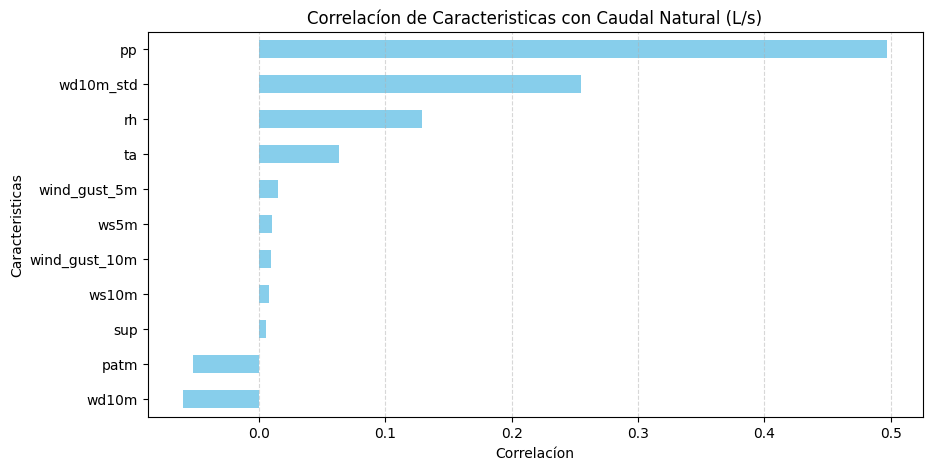

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# select numeric features only (excluding the target itself)
features = [
    'rh', 'sup', 'ta', 'ws10m', 'wd10m', 'wd10m_std', 'ws5m',
    'pp', 'wind_gust_5m', 'wind_gust_10m', 'patm'
]

# ensure columns exist
features = [f for f in features if f in df_data.columns]

# compute correlation with target
corr_with_target = df_data[features + ['Caudal (L/s)']].corr()['Caudal (L/s)'].drop('Caudal (L/s)')

# display correlations
print(corr_with_target)

# plot as bar chart
plt.figure(figsize=(10,5))
corr_with_target.sort_values().plot(kind='barh', color='skyblue')
plt.title('Correlacíon de Caracteristicas con Caudal Natural (L/s)')
plt.xlabel('Correlacíon')
plt.ylabel('Caracteristicas')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


In [16]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -----------------------
# Dataset class
# -----------------------
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y, seq_len=30):
        """
        X: numpy array or torch tensor of shape (num_samples, num_features)
        y: numpy array or torch tensor of shape (num_samples, 1)
        seq_len: length of LSTM input sequence
        """
        self.seq_len = seq_len
        # ensure numpy arrays
        X = np.array(X)
        y = np.array(y)

        # find sequences without NaNs
        valid_idx = []
        for i in range(len(X) - seq_len):
            seq_x = X[i:i+seq_len]
            seq_y = y[i+seq_len]
            if not np.isnan(seq_x).any() and not np.isnan(seq_y):
                valid_idx.append(i)
        
        self.X = X
        self.y = y
        self.valid_idx = valid_idx
        
    def __len__(self):
        return len(self.valid_idx)
    
    def __getitem__(self, idx):
        i = self.valid_idx[idx]
        return (torch.tensor(self.X[i:i+self.seq_len], dtype=torch.float32),
                torch.tensor(self.y[i+self.seq_len], dtype=torch.float32))


# -----------------------
# LSTM model
# -----------------------
class LSTMForecast(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:,-1,:]  # take last output
        out = self.fc(out)
        return out

# -----------------------
# Main LSTM pipeline
# -----------------------
def run_lstm_pipeline(df, val_start, forecast_end, seq_len=30, batch_size=64, epochs=50, lr=1e-3, device='cpu'):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp')
    
    # select numeric features
    numeric_cols = ['rh', 'sup', 'ta', 'ws10m', 'wd10m', 'wd10m_std', 'ws5m',
                    'pp', 'wind_gust_5m', 'wind_gust_10m', 'Caudal (L/s)']
    df[numeric_cols] = df[numeric_cols].ffill().fillna(df[numeric_cols].median())
    
    # split into train and validation
    val_start = pd.to_datetime(val_start, format="%Y%m%d")
    forecast_end = pd.to_datetime(forecast_end, format="%Y%m%d")
    
    df_train = df[df['timestamp'] < val_start].reset_index(drop=True)
    df_val_forecast = df[df['timestamp'] >= val_start].reset_index(drop=True)
    
    # scale features and target
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_train = scaler_X.fit_transform(df_train[numeric_cols].drop(columns=['Caudal (L/s)']))
    y_train = scaler_y.fit_transform(df_train[['Caudal (L/s)']])
    
    X_val = scaler_X.transform(df_val_forecast[numeric_cols].drop(columns=['Caudal (L/s)']))
    y_val = scaler_y.transform(df_val_forecast[['Caudal (L/s)']])
    
    # create datasets
    train_dataset = TimeSeriesDataset(torch.tensor(X_train, dtype=torch.float32),
                                      torch.tensor(y_train, dtype=torch.float32),
                                      seq_len=seq_len)
    
    val_dataset = TimeSeriesDataset(torch.tensor(X_val, dtype=torch.float32),
                                    torch.tensor(y_val, dtype=torch.float32),
                                    seq_len=seq_len)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # model
    model = LSTMForecast(input_size=X_train.shape[1]).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # training loop
    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
        
        # validation loss
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss += criterion(out, yb).item()
        val_loss /= len(val_loader)
        if epoch % 10 == 0 or epoch == epochs-1:
            print(f"Epoch {epoch+1}/{epochs} | Validation Loss: {val_loss:.4f}")
    
    # -----------------------
    # Forecast
    # -----------------------
    model.eval()
    X_full = scaler_X.transform(df[numeric_cols].drop(columns=['Caudal (L/s)']))
    X_full_tensor = torch.tensor(X_full, dtype=torch.float32).unsqueeze(0).to(device)
    
    preds = []
    seq = X_full_tensor[:,:seq_len,:]  # initial sequence
    
    for i in range(len(df) - seq_len):
        with torch.no_grad():
            y_pred = model(seq).cpu().numpy()
        preds.append(y_pred[0,0])
        # slide the window
        next_input = X_full_tensor[:,i+seq_len,:].unsqueeze(1)
        seq = torch.cat([seq[:,1:,:], next_input], dim=1)
    
    preds = scaler_y.inverse_transform(np.array(preds).reshape(-1,1)).ravel()
    
    # prepare timestamps
    timestamps = df['timestamp'][seq_len:].reset_index(drop=True)
    
    # plot
    plt.figure(figsize=(14,6))
    plt.plot(df['timestamp'], df['Caudal (L/s)'], label='real', color='blue')
    plt.plot(timestamps, preds, label='prediction', linestyle='--', color='orange', alpha=0.7)
    plt.axvline(val_start, color='red', linestyle='--', label='val start')
    #plt.axvline(forecast_end, color='red', linestyle='--', label='Forecast end')
    plt.xlabel('Timestamp')
    plt.ylabel('Caudal (L/s)')
    plt.title('LSTM Forecast')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return model, preds, scaler_X, scaler_y

# -----------------------
# Example usage
# -----------------------
model, preds, scaler_X, scaler_y = run_lstm_pipeline(
    df_data,
    val_start="20250701",
    forecast_end="20250913",
    seq_len=24*30,
    epochs=50,
    batch_size=64,
    lr=1e-3,
    device='cuda'
)


/tmp/ipykernel_1205906/2091681754.py:21: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  X = np.array(X)
/tmp/ipykernel_1205906/2091681754.py:22: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y = np.array(y)


RuntimeError: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero.

Epoch 1/50 - Loss: 0.029847
Epoch 2/50 - Loss: 0.015175
Epoch 3/50 - Loss: 0.013079
Epoch 4/50 - Loss: 0.012440
Epoch 5/50 - Loss: 0.012066
Epoch 6/50 - Loss: 0.011792
Epoch 7/50 - Loss: 0.011613
Epoch 8/50 - Loss: 0.011459
Epoch 9/50 - Loss: 0.011391
Epoch 10/50 - Loss: 0.011186
Epoch 11/50 - Loss: 0.011115
Epoch 12/50 - Loss: 0.011073
Epoch 13/50 - Loss: 0.010981
Epoch 14/50 - Loss: 0.010975
Epoch 15/50 - Loss: 0.010875
Epoch 16/50 - Loss: 0.010787
Epoch 17/50 - Loss: 0.010790
Epoch 18/50 - Loss: 0.010720
Epoch 19/50 - Loss: 0.010745
Epoch 20/50 - Loss: 0.010685
Epoch 21/50 - Loss: 0.010637
Epoch 22/50 - Loss: 0.010580
Epoch 23/50 - Loss: 0.010570
Epoch 24/50 - Loss: 0.010530
Epoch 25/50 - Loss: 0.010513
Epoch 26/50 - Loss: 0.010502
Epoch 27/50 - Loss: 0.010455
Epoch 28/50 - Loss: 0.010421
Epoch 29/50 - Loss: 0.010414
Epoch 30/50 - Loss: 0.010342
Epoch 31/50 - Loss: 0.010361
Epoch 32/50 - Loss: 0.010315
Epoch 33/50 - Loss: 0.010276
Epoch 34/50 - Loss: 0.010266
Epoch 35/50 - Loss: 0.0

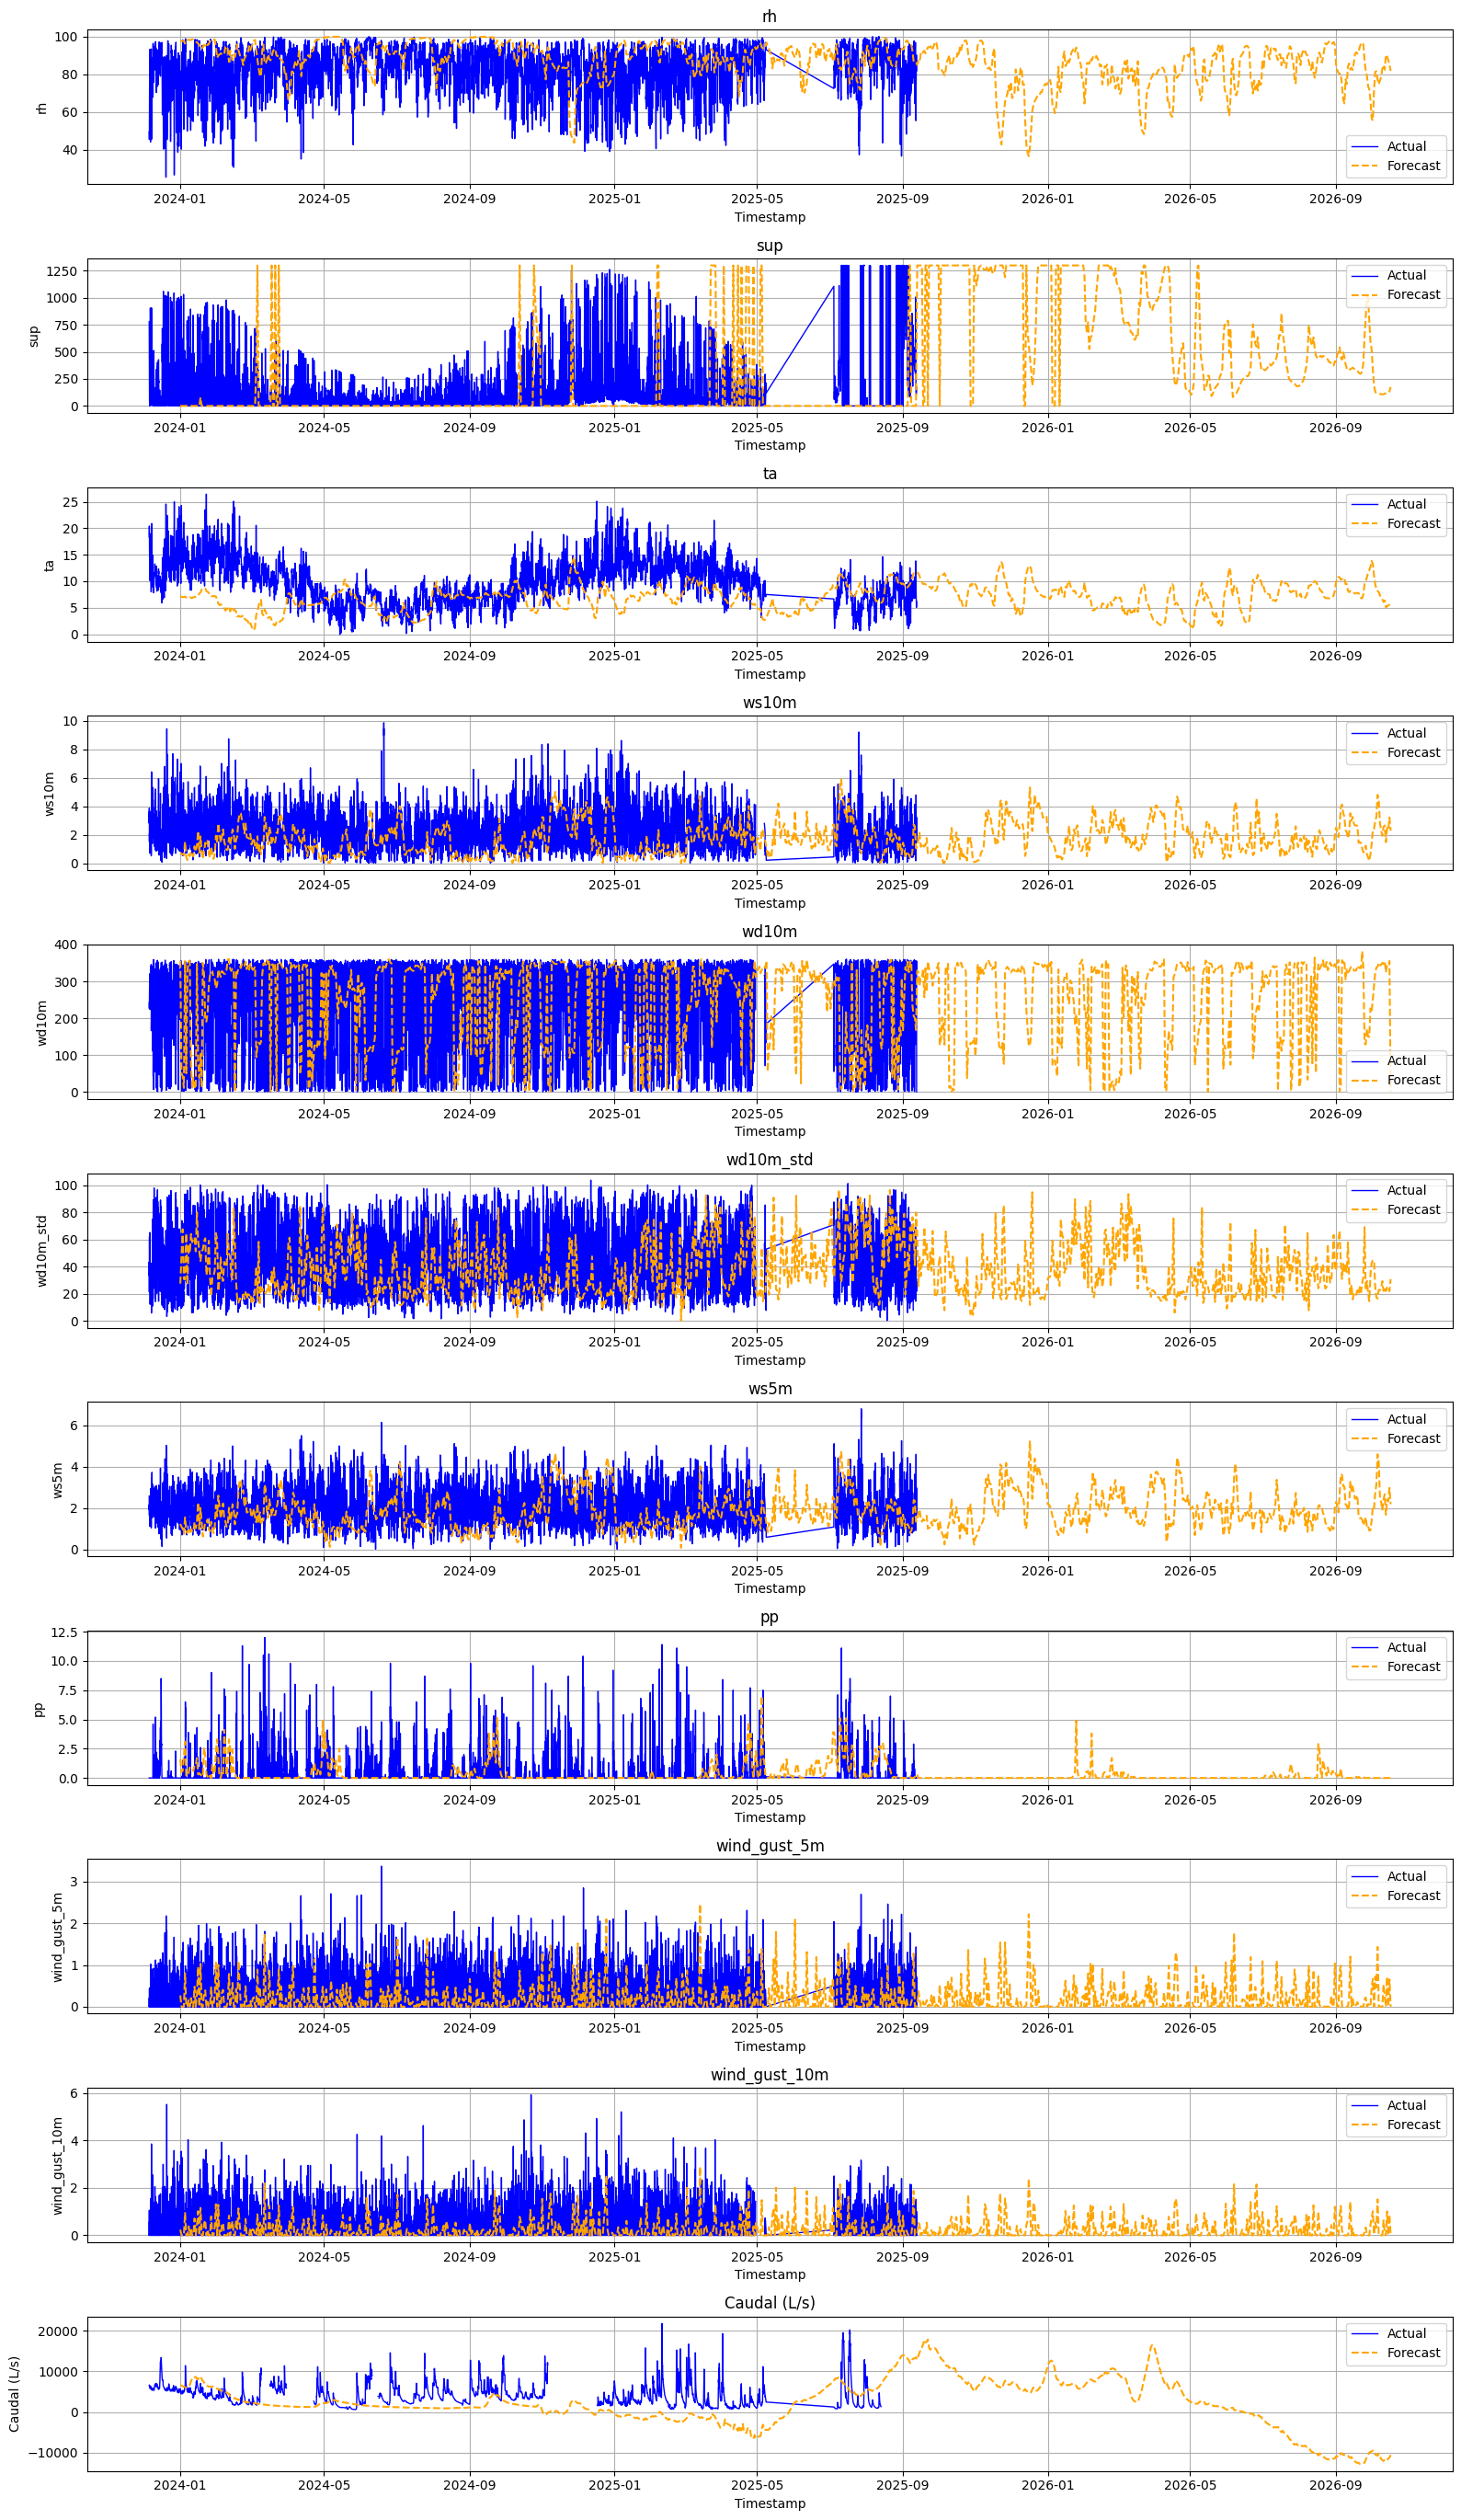

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd

# -----------------------------
# Dataset
# -----------------------------
class MultivariateSequenceDataset(Dataset):
    def __init__(self, df, feature_cols, seq_len=30, target_cols=None):
        """
        df: pandas DataFrame sorted by timestamp
        feature_cols: list of features to include
        seq_len: length of input sequences
        target_cols: columns to predict (default all features)
        """
        self.seq_len = seq_len
        self.feature_cols = feature_cols
        self.target_cols = target_cols if target_cols is not None else feature_cols
        
        data = df[feature_cols].values.astype(np.float32)
        self.data = data
        self.sequences = []
        self.targets = []

        for i in range(len(data) - seq_len):
            x_seq = data[i:i+seq_len]
            y_seq = data[i+seq_len, [feature_cols.index(c) for c in self.target_cols]]
            
            # Only keep sequences without NaNs
            if np.isfinite(x_seq).all() and np.isfinite(y_seq).all():
                self.sequences.append(x_seq)
                self.targets.append(y_seq)

        self.sequences = np.array(self.sequences)
        self.targets = np.array(self.targets)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.targets[idx])

# -----------------------------
# LSTM Model
# -----------------------------
class MultivariateLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.output_dim = output_dim if output_dim is not None else input_dim
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, self.output_dim)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

# -----------------------------
# Training function
# -----------------------------
def train_lstm(df, feature_cols, target_cols=None, seq_len=30, epochs=50, lr=1e-3,
               batch_size=64, validation_start=None, forecast_end=None, device='cpu'):
    
    df = df.sort_values('timestamp').reset_index(drop=True)
    scaler = MinMaxScaler()
    df_scaled = df.copy()
    df_scaled[feature_cols] = scaler.fit_transform(df_scaled[feature_cols])
    
    dataset = MultivariateSequenceDataset(df_scaled, feature_cols, seq_len, target_cols)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    input_dim = len(feature_cols)
    output_dim = len(target_cols) if target_cols is not None else input_dim
    model = MultivariateLSTM(input_dim, output_dim=output_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * X_batch.size(0)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(dataset):.6f}")
    
    # -----------------------------
    # Forecasting with missing values
    # -----------------------------
    model.eval()
    data_scaled = df_scaled[feature_cols].values.astype(np.float32)
    forecast_list = []
    
    # Determine start index for validation/forecast
    if validation_start is not None:
        val_idx = df[df['timestamp'] >= validation_start].index[0]o',
    else:
        val_idx = len(df) - seq_len
    
    if forecast_end is not None:
        end_idx = df[df['timestamp'] <= forecast_end].index[-1]
    else:
        end_idx = len(df) - 1
    
    input_seq = data_scaled[val_idx - seq_len:val_idx].copy()
    
    for i in range(val_idx, end_idx+1):
        x_input = torch.tensor(input_seq[-seq_len:], dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            y_pred = model(x_input).cpu().numpy().flatten()
        # replace missing features with prediction
        next_step = data_scaled[i].copy()
        nan_mask = ~np.isfinite(next_step)
        next_step[nan_mask] = y_pred[nan_mask]
        forecast_list.append(next_step)
        input_seq = np.vstack([input_seq, next_step])
    
    forecast_array = np.array(forecast_list)
    
    # Inverse transform to original scale
    forecast_array_orig = scaler.inverse_transform(forecast_array)
    
    return model, forecast_array_orig, scaler

import matplotlib.pyplot as plt

def plot_multivariate_forecast(df, feature_cols, forecast_array, start_timestamp=None, title_suffix=''):
    """
    df: original dataframe
    feature_cols: list of features
    forecast_array: numpy array of forecasted features (same order as feature_cols)
    start_timestamp: string or pd.Timestamp, starting time of forecast (should match first forecasted row)
    """
    plt.figure(figsize=(16, len(feature_cols)*2.5))
    
    # Determine forecast timestamps
    if start_timestamp is None:
        start_idx = 0
        forecast_timestamps = df['timestamp'].iloc[start_idx:start_idx+len(forecast_array)]
    else:
        start_timestamp = pd.to_datetime(start_timestamp)
        # Generate forecast timestamps assuming same frequency as df
        freq = pd.infer_freq(df['timestamp'])
        if freq is None:
            freq = 'D'  # fallback
        forecast_timestamps = pd.date_range(start=start_timestamp, periods=len(forecast_array), freq=freq)
    
    for i, col in enumerate(feature_cols):
        plt.subplot(len(feature_cols), 1, i+1)
        # historical data
        plt.plot(df['timestamp'], df[col], label='Actual', color='blue', linewidth=1)
        # forecasted data overlapping actuals
        plt.plot(forecast_timestamps, forecast_array[:, i], label='Forecast', color='orange', linestyle='--')
        
        # optionally, shade the forecasted region
        #plt.axvspan(forecast_timestamps[0], forecast_timestamps[-1], color='red', alpha=0.05)
        
        plt.title(col)
        plt.xlabel('Timestamp')
        plt.ylabel(col)
        plt.legend()
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()


feature_cols = ['rh', 'sup', 'ta', 'ws10m', 'wd10m', 'wd10m_std', 
                'ws5m', 'pp', 'wind_gust_5m', 'wind_gust_10m', 'Caudal (L/s)']

# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Train LSTM
model, forecast_array, scaler = train_lstm(
    df=df_data,
    feature_cols=feature_cols,
    seq_len=30,
    epochs=50,
    lr=1e-3,
    batch_size=64,
    validation_start="20250801",  # start of validation/forecast
    forecast_end="20250913",      # end of forecast
    device=device
)

# Plot all features forecast
start_idx = df_data[df_data['timestamp'] >= "20230801"].index[0]
plot_multivariate_forecast(
    df_data,
    feature_cols, 
    forecast_array,
    start_timestamp="20240101"
)


Validation RMSE: 3418835.042
Missing values filled successfully!


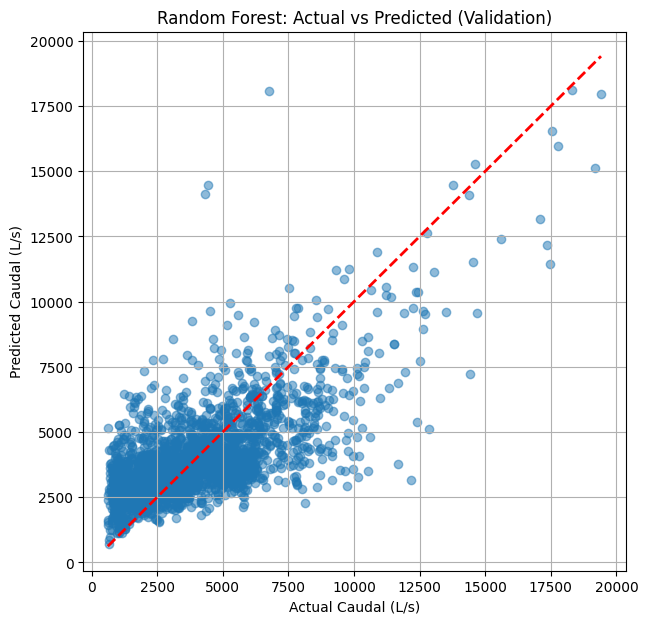

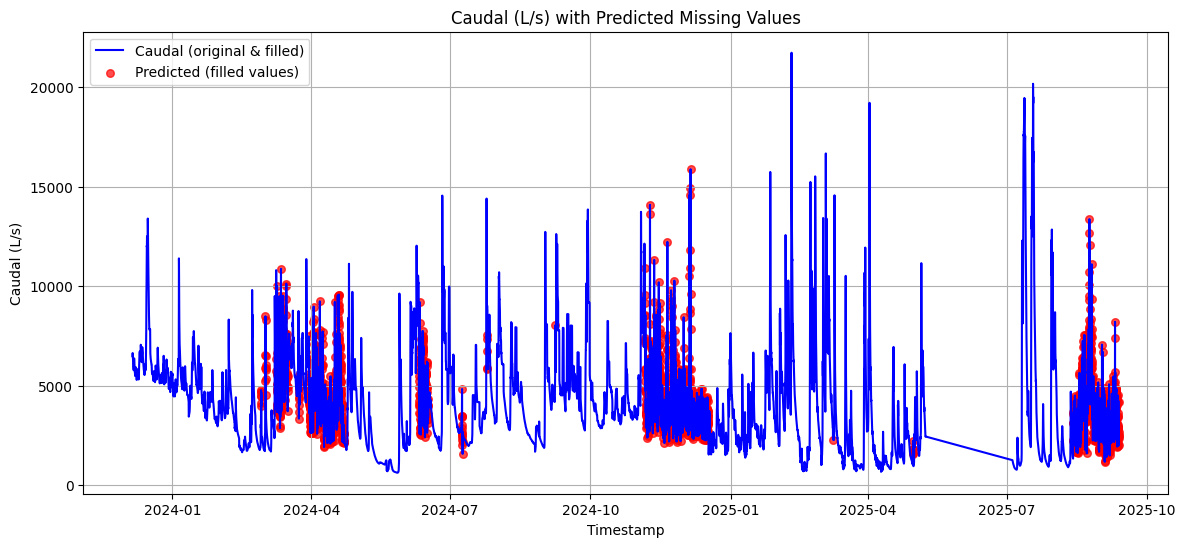

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Suppose your dataframe is called df
# Features (all except timestamp and Caudal)
feature_cols = ['rh', 'sup', 'ta', 'ws10m', 'wd10m', 'wd10m_std',
                'ws5m', 'pp', 'wind_gust_5m', 'wind_gust_10m', 'patm']

target_col = 'Caudal (L/s)'

# Split rows into trainable and missing target
df_train = df_data[df_data[target_col].notna()].copy()
df_missing = df_data[df_data[target_col].isna()].copy()

# Prepare features/target for training
X = df_train[feature_cols]
y = df_train[target_col]

# Handle missing values in input features
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# Train/validation split for evaluation
X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_val)
rmse = mean_squared_error(y_val, y_pred)
print(f"Validation RMSE: {rmse:.3f}")


print("Missing values filled successfully!")

import matplotlib.pyplot as plt

# --- Scatter plot: actual vs predicted ---
plt.figure(figsize=(7, 7))
plt.scatter(y_val, y_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--', lw=2)  # 1:1 line
plt.xlabel("Actual Caudal (L/s)")
plt.ylabel("Predicted Caudal (L/s)")
plt.title("Random Forest: Actual vs Predicted (Validation)")
plt.grid(True)
plt.show()

# --- Time series plot with filled missing values ---
plt.figure(figsize=(14, 6))
plt.plot(df_data["timestamp"], df_data[target_col], label="Caudal (original & filled)", color="blue")
plt.scatter(df_missing["timestamp"], 
            df_data.loc[df_missing.index, target_col],
            label="Predicted (filled values)",
            color="red", s=30, alpha=0.7)
plt.xlabel("Timestamp")
plt.ylabel("Caudal (L/s)")
plt.title("Caudal (L/s) with Predicted Missing Values")
plt.legend()
plt.grid(True)
plt.show()

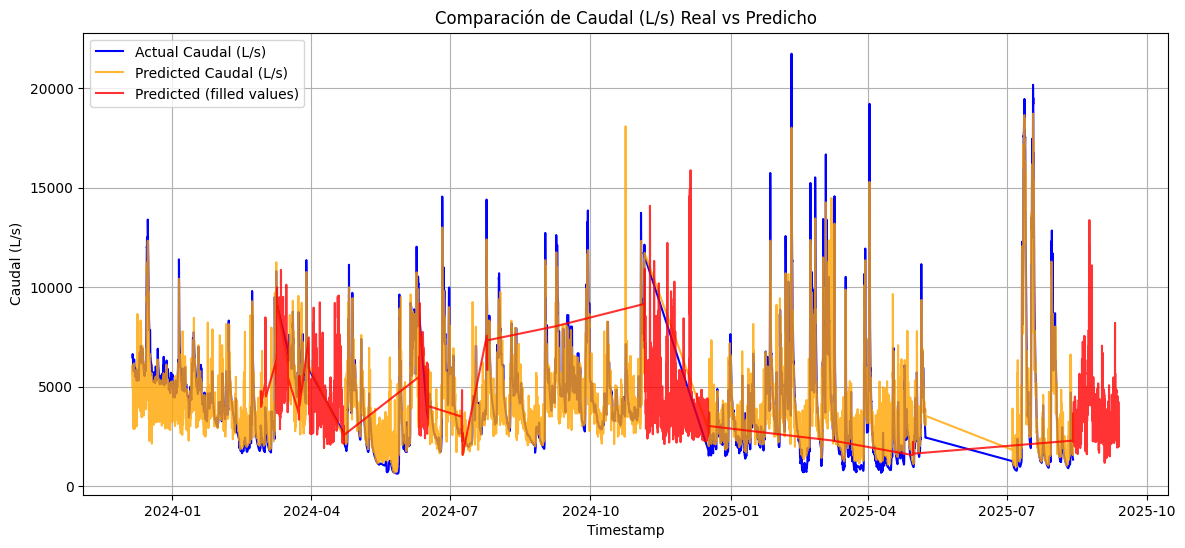

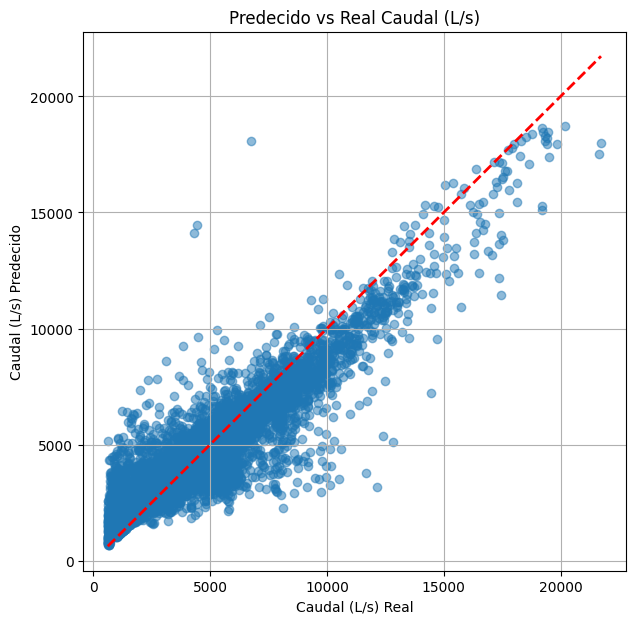

In [19]:
# Get predictions for all known samples
X_all = imputer.transform(df_train[feature_cols])
y_all = df_train[target_col]
y_all_pred = rf.predict(X_all)

# --- Line plot: real vs predicted over all samples ---
plt.figure(figsize=(14, 6))
plt.plot(df_train["timestamp"], y_all, label="Actual Caudal (L/s)", color="blue")
plt.plot(df_train["timestamp"], y_all_pred, label="Predicted Caudal (L/s)", color="orange", alpha=0.8)
plt.plot(df_missing["timestamp"], 
            df_data.loc[df_missing.index, target_col],
            label="Predicted (filled values)", alpha=0.8, color="red")
plt.xlabel("Timestamp")
plt.ylabel("Caudal (L/s)")
plt.title("Comparación de Caudal (L/s) Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

# --- Scatter plot: all actual vs predicted ---
plt.figure(figsize=(7, 7))
plt.scatter(y_all, y_all_pred, alpha=0.5)
plt.plot([y_all.min(), y_all.max()],
         [y_all.min(), y_all.max()],
         'r--', lw=2)
plt.xlabel("Caudal (L/s) Real")
plt.ylabel("Caudal (L/s) Predecido")
plt.title("Predecido vs Real Caudal (L/s)")
plt.grid(True)
plt.show()


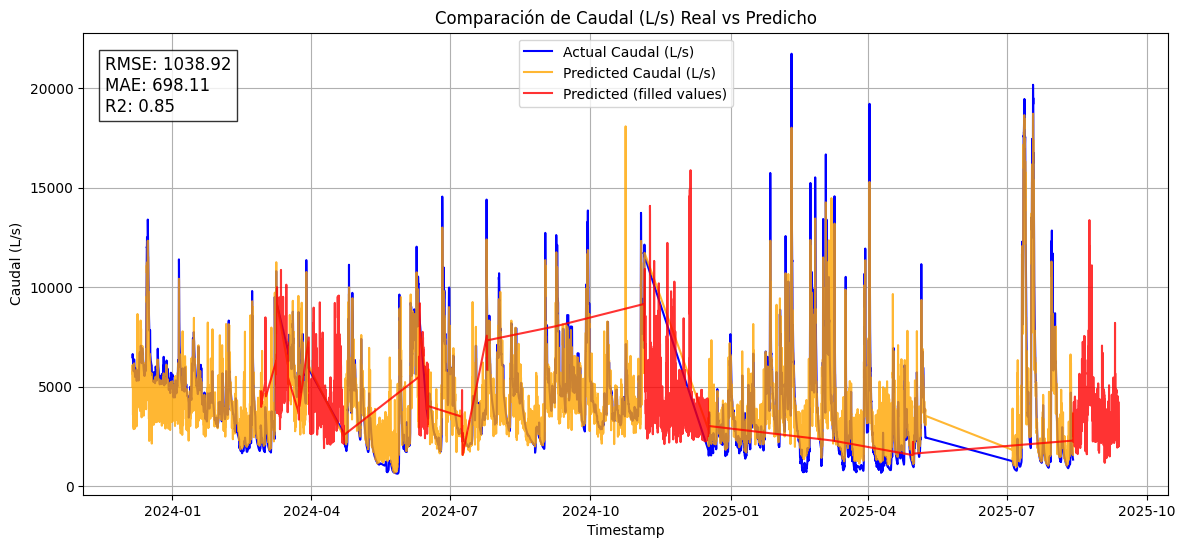

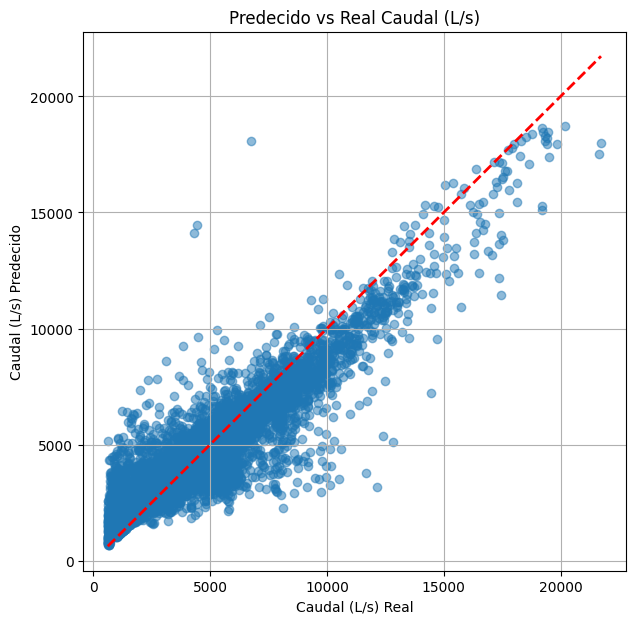

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import matplotlib.pyplot as plt

# --- Predictions ---
X_all = imputer.transform(df_train[feature_cols])
y_all = df_train[target_col]
y_all_pred = rf.predict(X_all)

# --- Calculate metrics ---
rmse = sqrt(mean_squared_error(y_all, y_all_pred))
mae = mean_absolute_error(y_all, y_all_pred)
r2 = r2_score(y_all, y_all_pred)

# --- Line plot: real vs predicted over all samples ---
plt.figure(figsize=(14, 6))
plt.plot(df_train["timestamp"], y_all, label="Actual Caudal (L/s)", color="blue")
plt.plot(df_train["timestamp"], y_all_pred, label="Predicted Caudal (L/s)", color="orange", alpha=0.8)
plt.plot(df_missing["timestamp"], 
         df_data.loc[df_missing.index, target_col],
         label="Predicted (filled values)", alpha=0.8, color="red")
plt.xlabel("Timestamp")
plt.ylabel("Caudal (L/s)")
plt.title("Comparación de Caudal (L/s) Real vs Predicho")
plt.legend()
plt.grid(True)

# --- Add metrics box ---
metrics_text = f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR2: {r2:.2f}"
plt.gca().text(0.02, 0.95, metrics_text, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# --- Scatter plot: all actual vs predicted ---
plt.figure(figsize=(7, 7))
plt.scatter(y_all, y_all_pred, alpha=0.5)
plt.plot([y_all.min(), y_all.max()],
         [y_all.min(), y_all.max()],
         'r--', lw=2)
plt.xlabel("Caudal (L/s) Real")
plt.ylabel("Caudal (L/s) Predecido")
plt.title("Predecido vs Real Caudal (L/s)")
plt.grid(True)
plt.show()


/home/jose/Desktop/projects/MOWI/.venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Performance on Known Samples:
  RMSE = 1900.129
  MAE  = 1450.413
  R²   = 0.488


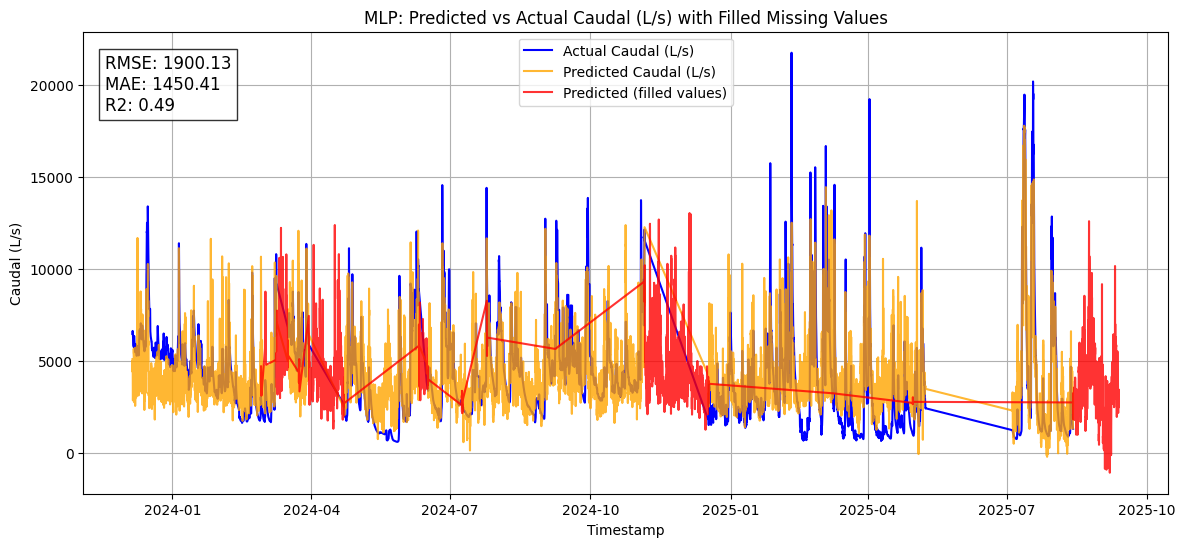

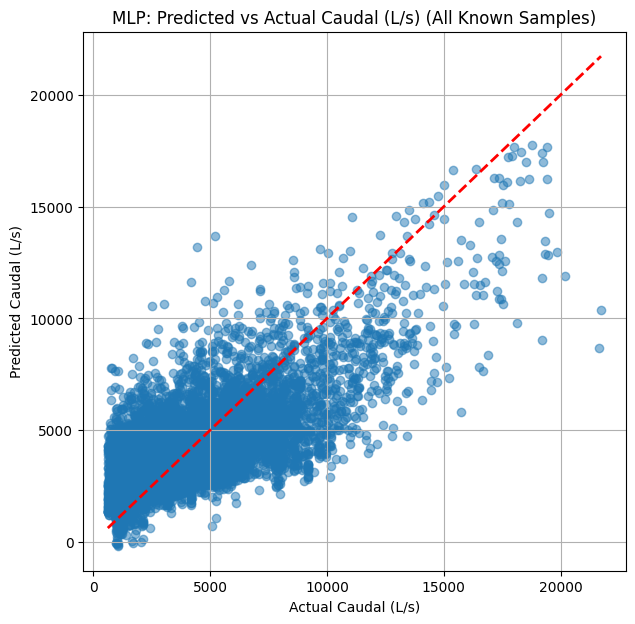

Missing values filled using MLP model.


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from math import sqrt

# --------------------------
# Setup
# --------------------------
feature_cols = ['rh', 'sup', 'ta', 'ws10m', 'wd10m', 'wd10m_std',
                'ws5m', 'pp', 'wind_gust_5m', 'wind_gust_10m', 'patm']
target_col = 'Caudal (L/s)'

# Split into known target (train) and missing target (predict)
df_train = df_data[df_data[target_col].notna()].copy()
df_missing = df_data[df_data[target_col].isna()].copy()

X = df_train[feature_cols]
y = df_train[target_col]

# --------------------------
# Preprocessing
# --------------------------
imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

# --------------------------
# Train MLP
# --------------------------
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),   # two hidden layers
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

mlp.fit(X_scaled, y)

# --------------------------
# Predictions
# --------------------------
# Known samples
y_all_pred = mlp.predict(X_scaled)

# Missing samples
X_missing = scaler.transform(imputer.transform(df_missing[feature_cols]))
y_missing_pred = mlp.predict(X_missing)

# --------------------------
# Metrics
# --------------------------
rmse = sqrt(mean_squared_error(y, y_all_pred))
mae = mean_absolute_error(y, y_all_pred)
r2 = r2_score(y, y_all_pred)

print(f"MLP Performance on Known Samples:")
print(f"  RMSE = {rmse:.3f}")
print(f"  MAE  = {mae:.3f}")
print(f"  R²   = {r2:.3f}")

# --------------------------
# Visualization
# --------------------------
# Line plot (with missing predictions)
plt.figure(figsize=(14, 6))
plt.plot(df_train["timestamp"], y, label="Actual Caudal (L/s)", color="blue")
plt.plot(df_train["timestamp"], y_all_pred, label="Predicted Caudal (L/s)", color="orange", alpha=0.8)
plt.plot(df_missing["timestamp"], y_missing_pred, label="Predicted (filled values)", color="red", alpha=0.8)
plt.xlabel("Timestamp")
plt.ylabel("Caudal (L/s)")
plt.title("MLP: Predicted vs Actual Caudal (L/s) with Filled Missing Values")
plt.legend()
plt.grid(True)

# Add metrics box
metrics_text = f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR2: {r2:.2f}"
plt.gca().text(0.02, 0.95, metrics_text, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# Scatter plot (actual vs predicted known samples)
plt.figure(figsize=(7, 7))
plt.scatter(y, y_all_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Caudal (L/s)")
plt.ylabel("Predicted Caudal (L/s)")
plt.title("MLP: Predicted vs Actual Caudal (L/s) (All Known Samples)")
plt.grid(True)
plt.show()

# --------------------------
# Predict missing values (optional)
# --------------------------
print("Missing values filled using MLP model.")



In [ ]:
# Get predictions for all known samples
X_all = imputer.transform(df_train[feature_cols])
y_all = df_train[target_col]
y_all_pred = rf.predict(X_all)

# --- Line plot: real vs predicted over all samples ---
plt.figure(figsize=(14, 6))
plt.plot(df_train["timestamp"], y_all, label="Actual Caudal (L/s)", color="blue")
plt.plot(df_train["timestamp"], y_all_pred, label="Predicted Caudal (L/s)", color="orange", alpha=0.8)
plt.plot(df_missing["timestamp"], 
            df_data.loc[df_missing.index, target_col],
            label="Predicted (filled values)", alpha=0.8, color="red")
plt.xlabel("Timestamp")
plt.ylabel("Caudal (L/s)")
plt.title("Comparación de Caudal (L/s) Real vs Predicho")
plt.legend()
plt.grid(True)
plt.show()

# --- Scatter plot: all actual vs predicted ---
plt.figure(figsize=(7, 7))
plt.scatter(y_all, y_all_pred, alpha=0.5)
plt.plot([y_all.min(), y_all.max()],
         [y_all.min(), y_all.max()],
         'r--', lw=2)
plt.xlabel("Caudal (L/s) Real")
plt.ylabel("Caudal (L/s) Predecido")
plt.title("Predecido vs Real Caudal (L/s)")
plt.grid(True)
plt.show()


Epoch 10/50, Loss: 0.5179
Epoch 20/50, Loss: 0.4652
Epoch 30/50, Loss: 0.4178
Epoch 40/50, Loss: 0.3828
Epoch 50/50, Loss: 0.3566
CNN Performance on Known Samples:
  RMSE = 1541.731
  MAE  = 1191.306
  R²   = 0.663


/home/jose/Desktop/projects/MOWI/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SimpleImputer was fitted without feature names
  warnings.warn(


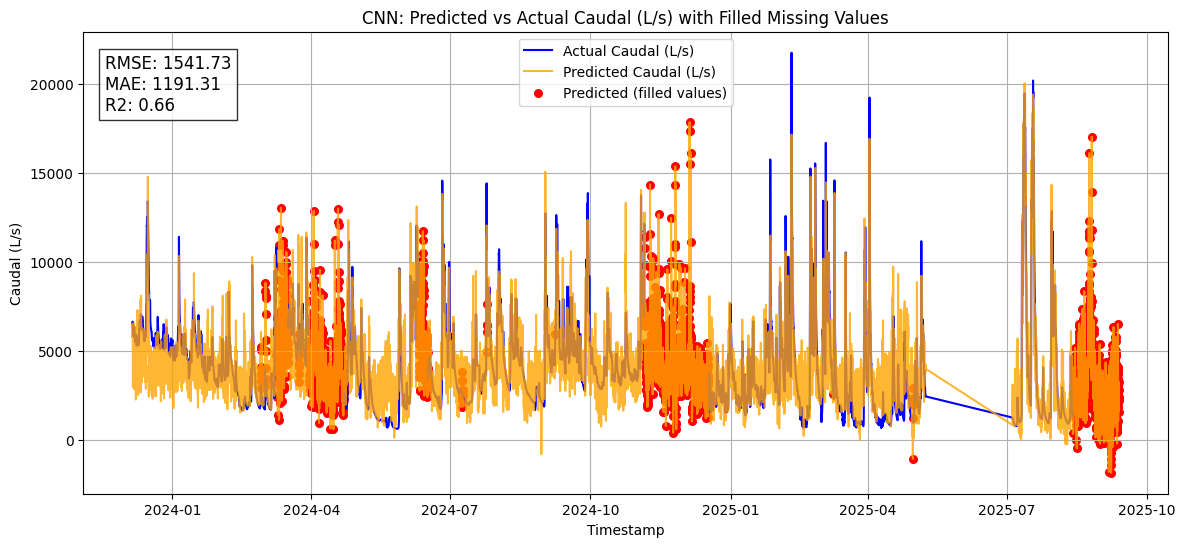

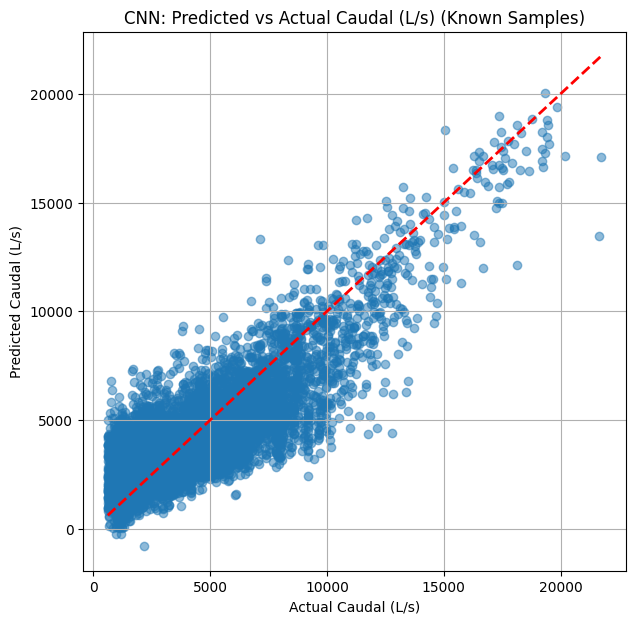

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

# --------------------------
# Setup
# --------------------------
feature_cols = ['rh', 'sup', 'ta', 'ws10m', 'wd10m', 'wd10m_std',
                'ws5m', 'pp', 'wind_gust_5m', 'wind_gust_10m', 'patm']
target_col = 'Caudal (L/s)'

df_train = df_data[df_data[target_col].notna()].copy()
df_missing = df_data[df_data[target_col].isna()].copy()

X = df_train[feature_cols].values
y = df_train[target_col].values.reshape(-1, 1)

# --------------------------
# Preprocessing
# --------------------------
imputer = SimpleImputer(strategy="mean")
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler_X.fit_transform(X_imputed)
y_scaled = scaler_y.fit_transform(y)

# Convert to torch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(1)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# --------------------------
# CNN Model
# --------------------------
class ConvRegressor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(32 * n_features, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

n_features = len(feature_cols)
model = ConvRegressor(n_features)

# --------------------------
# Training
# --------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 50
model.train()
for epoch in range(epochs):
    epoch_loss = 0
    for xb, yb in dataloader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataset):.4f}")

# --------------------------
# Predict on all samples
# --------------------------
model.eval()

# Scale all features
X_all_imputed = imputer.transform(df_data[feature_cols])
X_all_scaled = scaler_X.transform(X_all_imputed)
X_all_tensor = torch.tensor(X_all_scaled, dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    y_all_scaled = model(X_all_tensor).numpy()
    y_all_pred = scaler_y.inverse_transform(y_all_scaled).flatten()

# --------------------------
# Metrics (only on known samples)
# --------------------------
y_known_pred = y_all_pred[~df_data[target_col].isna()]
y_known_true = df_data.loc[~df_data[target_col].isna(), target_col].values

rmse = sqrt(mean_squared_error(y_known_true, y_known_pred))
mae = mean_absolute_error(y_known_true, y_known_pred)
r2 = r2_score(y_known_true, y_known_pred)

print(f"CNN Performance on Known Samples:")
print(f"  RMSE = {rmse:.3f}")
print(f"  MAE  = {mae:.3f}")
print(f"  R²   = {r2:.3f}")

# --------------------------
# Visualization
# --------------------------
plt.figure(figsize=(14, 6))
plt.plot(df_data["timestamp"], df_data[target_col], label="Actual Caudal (L/s)", color="blue")
plt.plot(df_data["timestamp"], y_all_pred, label="Predicted Caudal (L/s)", color="orange", alpha=0.8)
plt.scatter(df_missing["timestamp"], y_all_pred[df_data[target_col].isna()],
            label="Predicted (filled values)", color="red", s=30)
plt.xlabel("Timestamp")
plt.ylabel("Caudal (L/s)")
plt.title("CNN: Predicted vs Actual Caudal (L/s) with Filled Missing Values")
plt.legend()
plt.grid(True)

# Add metrics box
metrics_text = f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR2: {r2:.2f}"
plt.gca().text(0.02, 0.95, metrics_text, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# Scatter plot (actual vs predicted, known only)
plt.figure(figsize=(7, 7))
plt.scatter(y_known_true, y_known_pred, alpha=0.5)
plt.plot([y_known_true.min(), y_known_true.max()],
         [y_known_true.min(), y_known_true.max()], 'r--', lw=2)
plt.xlabel("Actual Caudal (L/s)")
plt.ylabel("Predicted Caudal (L/s)")
plt.title("CNN: Predicted vs Actual Caudal (L/s) (Known Samples)")
plt.grid(True)
plt.show()



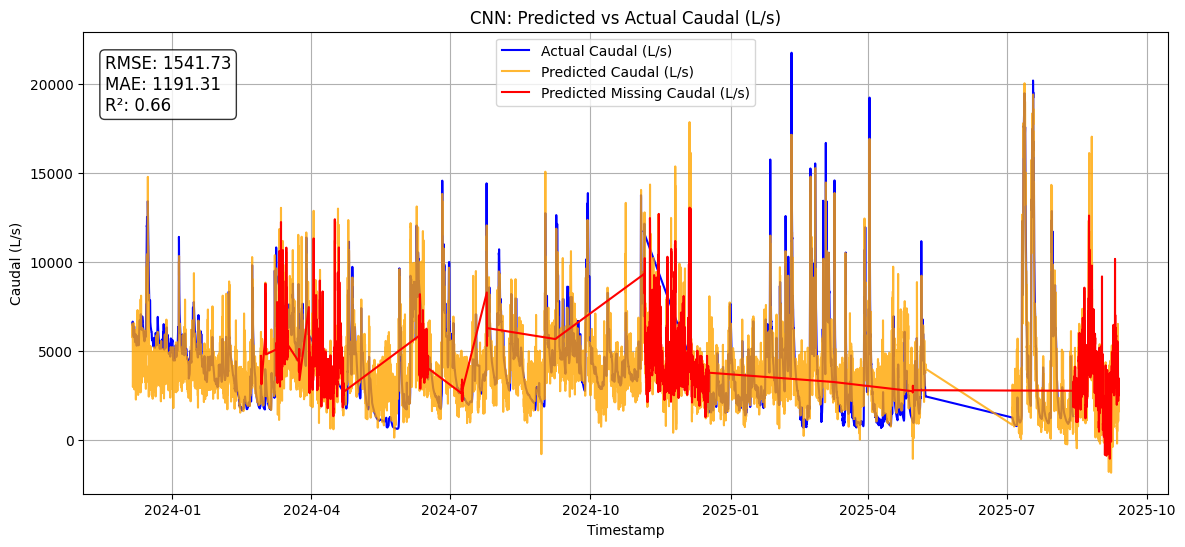

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# --- Calculate metrics (only where actuals exist) ---
y_true = df_data.loc[~df_data["Caudal (L/s)"].isna(), "Caudal (L/s)"].values
y_pred = y_all_pred[~df_data["Caudal (L/s)"].isna()]
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

# --- Plot ---
plt.figure(figsize=(14, 6))

# Actual values
plt.plot(df_data.loc[~df_data["Caudal (L/s)"].isna(), "timestamp"],
         y_true, label="Actual Caudal (L/s)", color="blue")

# Predictions (all samples)
plt.plot(df_data["timestamp"], y_all_pred, label="Predicted Caudal (L/s)", color="orange", alpha=0.8)

# Predictions for missing data in red
plt.plot(df_data.loc[df_data["Caudal (L/s)"].isna(), "timestamp"],
         y_missing_pred, 'r-', label="Predicted Missing Caudal (L/s)")

# Labels and formatting
plt.xlabel("Timestamp")
plt.ylabel("Caudal (L/s)")
plt.title("CNN: Predicted vs Actual Caudal (L/s)")
plt.legend()
plt.grid(True)

# --- Metrics box ---
metrics_text = f"RMSE: {rmse:.2f}\nMAE: {mae:.2f}\nR²: {r2:.2f}"
plt.gca().text(0.02, 0.95, metrics_text, transform=plt.gca().transAxes,
               fontsize=12, verticalalignment="top",
               bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.show()
